In [1]:
# --- Cell 1: Setup & Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display theme for publication-quality plots
sns.set_theme(style="whitegrid")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set path
GDrive_Path = '/content/drive/MyDrive/windforecast/'
print(f"Using path: {GDrive_Path}")

# Global variables
source_target_col = 'mean_wind_speed'
SEED = 42
np.random.seed(SEED)

# File paths
sarkoy_json_path = f"{GDrive_Path}data/Meteorology_Sarkoy_2014_2024.json"
trakya_csv_path = f"{GDrive_Path}data/wind_speed_trakya.csv"
ganos_csv_path = f"{GDrive_Path}data/Meteorology_Ganos_2016_Nov_2024.csv"

print("Cell 1: Setup Complete.")

Mounted at /content/drive
Using path: /content/drive/MyDrive/windforecast/
Cell 1: Setup Complete.


In [2]:
import pandas as pd
import numpy as np

# Load Şarköy Data (JSON)
df_sarkoy = pd.read_json(sarkoy_json_path)
df_sarkoy = df_sarkoy.reset_index().rename(columns={'index': 'date_time'})
df_sarkoy['date_time'] = pd.to_datetime(df_sarkoy['date_time'])

# Load Trakya Data (CSV)
df_trakya = pd.read_csv(trakya_csv_path, parse_dates=['date_time'])

# Load Ganos Data (CSV)
df_ganos = pd.read_csv(ganos_csv_path, parse_dates=['Date'])
df_ganos = df_ganos.rename(columns={'Date': 'date_time'})
df_ganos['date_time'] = pd.to_datetime(df_ganos['date_time'], errors='coerce')
df_ganos = df_ganos.dropna(subset=['date_time'])

# Merge DataFrames
df_merged_temp = pd.merge(df_sarkoy, df_trakya, on='date_time', how='inner', suffixes=('_sarkoy', '_trakya'))
df_merged_fe = pd.merge(df_merged_temp, df_ganos, on='date_time', how='inner')

# Clean redundant columns
redundant_cols = [col for col in df_merged_fe.columns if col.endswith('_trakya') and col.replace('_trakya', '') in df_merged_fe.columns]
df_merged_fe.drop(columns=redundant_cols, inplace=True)

# Set index and sort
df_merged_fe.set_index('date_time', inplace=True)
df_merged_fe.sort_index(inplace=True)

# Save merged DataFrame
output_file_fe1 = f"{GDrive_Path}df_FE1_merged.feather"
df_merged_fe.reset_index().to_feather(output_file_fe1)

print(f"Merged DataFrame shape: {df_merged_fe.shape}")
print(f"DataFrame saved to: {output_file_fe1}")
print(f"Columns: {list(df_merged_fe.columns)}")

/tmp/ipython-input-2-3535411597.py:10: DtypeWarning: Columns (9,11,93,105,107) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trakya = pd.read_csv(trakya_csv_path, parse_dates=['date_time'])


Merged DataFrame shape: (2983, 1295)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE1_merged.feather
Columns: ['max_pressure', 'max_humidity', 'max_wind_speed', 'max_wind_angle', 'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature', 'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_wind_angle', 'mean_temperature', 'total_precipitation', 'max_speed_cerkezkoy', 'max_wind_angle_cerkezkoy', 'max_wind_dir_cerkezkoy', 'mean_speed_cerkezkoy', 'mean_wind_dir_cerkezkoy', 'mean_wind_angle_cerkezkoy', 'max_speed_hamzebeyli', 'max_wind_angle_hamzebeyli', 'max_wind_dir_hamzebeyli', 'mean_speed_hamzebeyli', 'mean_wind_dir_hamzebeyli', 'mean_wind_angle_hamzebeyli', 'max_speed_meric', 'max_wind_angle_meric', 'max_wind_dir_meric', 'mean_speed_meric', 'mean_wind_dir_meric', 'mean_wind_angle_meric', 'max_speed_muratli', 'max_wind_angle_muratli', 'max_wind_dir_muratli', 'mean_speed_muratli', 'mean_wind_dir_muratli', 'mean_wind_angle_muratli', 'max_speed_kesan', 'max_

In [3]:
# Load merged DataFrame
merged_path = '/content/drive/MyDrive/windforecast/df_FE1_merged.feather'
df_merged_fe = pd.read_feather(merged_path)
df_merged_fe.set_index('date_time', inplace=True)

# Identify and drop columns with '_diff_'
cols_to_drop = [col for col in df_merged_fe.columns if '_diff_' in col]
print(f"Dropped columns: {cols_to_drop}")
df_merged_fe = df_merged_fe.drop(columns=cols_to_drop)

# Save cleaned DataFrame
output_file_fe2 = '/content/drive/MyDrive/windforecast/df_FE2_cleaned.feather'
df_merged_fe.reset_index().to_feather(output_file_fe2)

print(f"Cleaned DataFrame shape: {df_merged_fe.shape}")
print(f"DataFrame saved to: {output_file_fe2}")
print(f"Remaining columns: {df_merged_fe.columns.tolist()}")

Dropped columns: ['max_speed_diff_cerkezkoy_hamzebeyli', 'mean_speed_diff_cerkezkoy_hamzebeyli', 'max_speed_diff_cerkezkoy_meric', 'mean_speed_diff_cerkezkoy_meric', 'max_speed_diff_cerkezkoy_muratli', 'mean_speed_diff_cerkezkoy_muratli', 'max_speed_diff_cerkezkoy_kesan', 'mean_speed_diff_cerkezkoy_kesan', 'max_speed_diff_cerkezkoy_ipsala', 'mean_speed_diff_cerkezkoy_ipsala', 'max_speed_diff_cerkezkoy_enez', 'mean_speed_diff_cerkezkoy_enez', 'max_speed_diff_cerkezkoy_malkara', 'mean_speed_diff_cerkezkoy_malkara', 'max_speed_diff_cerkezkoy_sarkoy', 'mean_speed_diff_cerkezkoy_sarkoy', 'max_speed_diff_cerkezkoy_edirne', 'mean_speed_diff_cerkezkoy_edirne', 'max_speed_diff_cerkezkoy_tekirdag', 'mean_speed_diff_cerkezkoy_tekirdag', 'max_speed_diff_cerkezkoy_uzunkopru', 'mean_speed_diff_cerkezkoy_uzunkopru', 'max_speed_diff_cerkezkoy_saray', 'mean_speed_diff_cerkezkoy_saray', 'max_speed_diff_cerkezkoy_havsa', 'mean_speed_diff_cerkezkoy_havsa', 'max_speed_diff_cerkezkoy_hayrabolu', 'mean_speed

# Advanced Imputation and Wind Component Calculation
- **Purpose**: Calculate wind components and impute missing values using time series interpolation.
- **Input**: `df_FE1_merged.feather`
- **Output**: `df_FE2_cleaned_interpolated.feather`

In [4]:
# Load merged DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE2_cleaned.feather'
df_to_impute = pd.read_feather(input_file)
df_to_impute.set_index('date_time', inplace=True)

# Calculate wind components
def calculate_wind_components(df, speed_col, angle_col):
    df[f'{speed_col}_horizontal'] = -df[speed_col] * np.sin(np.radians(df[angle_col]))
    df[f'{speed_col}_vertical'] = -df[speed_col] * np.cos(np.radians(df[angle_col]))
    return df

wind_speed_cols = [col for col in df_to_impute.columns if 'speed' in col and 'angle' not in col]
wind_angle_cols = [col for col in df_to_impute.columns if 'angle' in col]
for speed_col, angle_col in zip(wind_speed_cols, wind_angle_cols):
    df_to_impute = calculate_wind_components(df_to_impute, speed_col, angle_col)

# Drop columns with >10% missing values
missing_percent = (df_to_impute.isnull().sum() / len(df_to_impute)) * 100
cols_to_drop = missing_percent[missing_percent > 10.0].index.tolist()
if cols_to_drop:
    df_to_impute = df_to_impute.drop(columns=cols_to_drop)
    print(f"Dropped columns with >10% NaNs: {cols_to_drop}")

# Time series interpolation for imputation
df_imputed = df_to_impute.interpolate(method='linear', limit_direction='both')

# Save imputed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE2_cleaned_interpolated.feather'
df_imputed.reset_index().to_feather(output_file)

print(f"Imputed DataFrame shape: {df_imputed.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Remaining NaNs: {df_imputed.isnull().sum().sum()}")


/tmp/ipython-input-4-1332619094.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{speed_col}_vertical'] = -df[speed_col] * np.cos(np.radians(df[angle_col]))
/tmp/ipython-input-4-1332619094.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{speed_col}_horizontal'] = -df[speed_col] * np.sin(np.radians(df[angle_col]))
/tmp/ipython-input-4-1332619094.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

Dropped columns with >10% NaNs: ['max_speed_hamzebeyli', 'max_wind_angle_hamzebeyli', 'max_wind_dir_hamzebeyli', 'mean_speed_hamzebeyli', 'mean_wind_dir_hamzebeyli', 'mean_wind_angle_hamzebeyli', 'max_speed_kemal', 'max_wind_angle_kemal', 'max_wind_dir_kemal', 'mean_speed_kemal', 'mean_wind_dir_kemal', 'mean_wind_angle_kemal', 'max_speed_havalimani', 'max_wind_angle_havalimani', 'max_wind_dir_havalimani', 'mean_speed_havalimani', 'mean_wind_dir_havalimani', 'mean_wind_angle_havalimani', 'max_speed_hamzebeyli_horizontal', 'max_speed_hamzebeyli_vertical', 'mean_speed_hamzebeyli_horizontal', 'mean_speed_hamzebeyli_vertical', 'max_speed_kemal_horizontal', 'max_speed_kemal_vertical', 'mean_speed_kemal_horizontal', 'mean_speed_kemal_vertical', 'max_speed_havalimani_horizontal', 'max_speed_havalimani_vertical', 'mean_speed_havalimani_horizontal', 'mean_speed_havalimani_vertical']
Imputed DataFrame shape: (2983, 185)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE2_cleaned_interp

**Notes**:
- Wind components (horizontal and vertical) are calculated to capture the directional nature of wind speed.
- Columns with more than 10% missing values are dropped to ensure data quality.
- Missing values are imputed using linear interpolation to preserve the time series structure and seasonality.

# Column Selection and Wind Angle Processing
- **Purpose**: Select relevant meteorological columns from Şarköy and Ganos, retain wind components from other stations, and convert wind angles to sin/cos components with interpolation.
- **Input**: `df_FE2_cleaned_interpolated.feather`
- **Output**: `df_FE3_selected_processed.feather`
- **Notes**:
  - Retains key meteorological data for Şarköy and Ganos.
  - Includes horizontal and vertical wind components from other stations to capture regional wind patterns.
  - Wind angles are converted to sin/cos components and interpolated to preserve circular data properties.

In [5]:
import pandas as pd
import numpy as np

# Load imputed DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE2_cleaned_interpolated.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# Define Şarköy and Ganos columns to retain
sarkoy_cols = [
    'max_pressure', 'max_humidity', 'max_wind_speed', 'max_wind_angle',
    'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature',
    'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_wind_angle',
    'mean_temperature', 'total_precipitation',
    # 'max_wind_speed_horizontal', 'max_wind_speed_vertical',
    # 'mean_wind_speed_horizontal', 'mean_wind_speed_vertical'
]
ganos_cols = [
    'max_humidity_at_ganos', 'max_temperature_at_ganos',
    'min_humidity_at_ganos', 'min_temperature_at_ganos',
    'mean_humidity_at_ganos', 'mean_temperature_at_ganos',
    'total_precipitation_at_ganos'
]

# Retain horizontalphysics horizontal/vertical components from other stations
other_cols = [col for col in df.columns if col.endswith('_horizontal') or col.endswith('_vertical')]
final_retain_cols = sarkoy_cols + ganos_cols + other_cols

# Select columns
df = df[final_retain_cols]

# Process wind angles to sin/cos components
angle_cols = [col for col in df.columns if '_angle' in col.lower() and '_sin' not in col.lower() and '_cos' not in col.lower()]
for angle_col in angle_cols:
    angle_rad = np.radians(df[angle_col])
    df[f'{angle_col}_sin'] = np.sin(angle_rad)
    df[f'{angle_col}_cos'] = np.cos(angle_rad)
    df[f'{angle_col}_sin'] = df[f'{angle_col}_sin'].interpolate(method='linear', limit_direction='both')
    df[f'{angle_col}_cos'] = df[f'{angle_col}_cos'].interpolate(method='linear', limit_direction='both')
    # Drop original angle columns
    df = df.drop(columns=angle_col)

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE3_selected_processed.feather'
df.reset_index().to_feather(output_file)

print(f"Processed DataFrame shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")

Processed DataFrame shape: (2983, 91)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE3_selected_processed.feather
Columns: ['max_pressure', 'max_humidity', 'max_wind_speed', 'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature', 'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_temperature', 'total_precipitation', 'max_humidity_at_ganos', 'max_temperature_at_ganos', 'min_humidity_at_ganos', 'min_temperature_at_ganos', 'mean_humidity_at_ganos', 'mean_temperature_at_ganos', 'total_precipitation_at_ganos', 'max_wind_speed_horizontal', 'max_wind_speed_vertical', 'mean_wind_speed_horizontal', 'mean_wind_speed_vertical', 'max_speed_cerkezkoy_horizontal', 'max_speed_cerkezkoy_vertical', 'mean_speed_cerkezkoy_horizontal', 'mean_speed_cerkezkoy_vertical', 'max_speed_meric_horizontal', 'max_speed_meric_vertical', 'mean_speed_meric_horizontal', 'mean_speed_meric_vertical', 'max_speed_muratli_horizontal', 'max_speed_muratli_vertical', 'mean_speed_muratli_horiz

# Feature Engineering: Lag, Seasonality, and Transformations
- **Purpose**: Add lag features for Şarköy and Ganos meteorological variables, mid wind speed, cyclical and categorical time features, daylight hours, and ratio/range transformations.
- **Input**: `df_FE3_selected_processed.feather`
- **Output**: `df_FE4_engineered.feather`
- **Notes**:
  - Lag features capture temporal dependencies for Şarköy and Ganos variables.
  - Cyclical (sin/cos) and one-hot encoded month features represent seasonality.
  - Absolute and squared wind components add non-linear relationships.
  - NaN and infinite values are handled to ensure data quality.

In [6]:
import pandas as pd
import numpy as np

# Load DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE3_selected_processed.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# NaN/Inf check before processing
if not df.index.is_monotonic_increasing:
    raise ValueError("Invalid dates in index, please check 'date_time'.")
if df.isna().any().any() or np.isinf(df).any().any():
    print(f"Initial NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df).sum().sum()}")

# Define variables for lag features (Şarköy and Ganos)
sarkoy_vars = [
    'mean_temperature', 'min_temperature', 'max_temperature',
    'mean_humidity', 'min_humidity', 'max_humidity',
    'mean_pressure', 'min_pressure', 'max_pressure',
    'total_precipitation', 'mean_wind_speed', 'max_wind_speed',
    'mean_wind_speed_horizontal', 'mean_wind_speed_vertical',
    'max_wind_speed_horizontal', 'max_wind_speed_vertical'
]
ganos_vars = [
    'mean_temperature_at_ganos', 'max_temperature_at_ganos', 'min_temperature_at_ganos',
    'mean_humidity_at_ganos', 'max_humidity_at_ganos', 'min_humidity_at_ganos',
    'total_precipitation_at_ganos'
]

# Create mid_wind_speed for Şarköy
if 'max_wind_speed' in df.columns and 'mean_wind_speed' in df.columns:
    df['mid_wind_speed'] = (df['max_wind_speed'] + df['mean_wind_speed']) / 2
    sarkoy_vars.append('mid_wind_speed')

# Add lag features
for var in sarkoy_vars + ganos_vars:
    if var in df.columns:
        df[f'lag_1_{var}'] = df[var].shift(1)
        df[f'lag_2_{var}'] = df[var].shift(2)

# Time and calendar features
df['year'] = df.index.year
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['day_of_week'] = df.index.dayofweek

# Fill NaN in month (if any)
if df['month'].isna().any():
    print(f"Found {df['month'].isna().sum()} NaNs in 'month', filling with mode.")
    df['month'] = df['month'].fillna(df['month'].mode()[0])

# Cyclical features for time components
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
season_mapping = {1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 4, 12: 1}
df['season_custom'] = df['month'].map(season_mapping)
df['season_custom_sin'] = np.sin(2 * np.pi * df['season_custom'] / 4)
df['season_custom_cos'] = np.cos(2 * np.pi * df['season_custom'] / 4)

# One-Hot Encoding for month (apply int only to dummy columns)
df = pd.get_dummies(df, columns=['month'], prefix='month')
dummy_cols = [col for col in df.columns if col.startswith('month_')]
df[dummy_cols] = df[dummy_cols].astype(int)

# Daylight hours
sarkoy_latitude_deg = 40.6152
delta_ang = -np.arcsin(0.39779 * np.cos(np.radians(0.98565 * (df['day_of_year'] + 10) + 1.914 * np.sin(np.radians(0.98565 * (df['day_of_year'] - 2))))))
cos_omega = -np.tan(np.radians(sarkoy_latitude_deg)) * np.tan(delta_ang)
cos_omega = np.clip(cos_omega, -1.0, 1.0)
omega = np.arccos(cos_omega)
df['daylight_hours'] = (2 * np.degrees(omega) / 15)
df['daylight_hours'] = df['daylight_hours'].fillna(12.0)
df['nightdark_hours'] = 24.0 - df['daylight_hours']

# Ratio and range features
epsilon = 1e-6
sarkoy_vars_dict = {
    'temp': ('mean_temperature', 'min_temperature', 'max_temperature'),
    'hum': ('mean_humidity', 'min_humidity', 'max_humidity'),
    'press': ('mean_pressure', 'min_pressure', 'max_pressure'),
    'wind': ('mean_wind_speed', None, 'max_wind_speed')
}
for var_type, (mean_col, min_col, max_col) in sarkoy_vars_dict.items():
    if all(c in df.columns for c in [mean_col, max_col]):
        df[f'sarkoy_{var_type}_mean_to_max_ratio'] = df[mean_col] / (df[max_col] + epsilon)
    if min_col is not None and all(c in df.columns for c in [mean_col, min_col, max_col]):
        df[f'sarkoy_{var_type}_range'] = df[max_col] - df[min_col]
        df[f'sarkoy_{var_type}_mean_relative_pos'] = (df[mean_col] - df[min_col]) / (df[f'sarkoy_{var_type}_range'] + epsilon)
        df[f'sarkoy_{var_type}_max_to_mean_ratio'] = df[max_col] / (df[mean_col] + epsilon)
        df[f'sarkoy_{var_type}_mean_to_min_ratio'] = df[mean_col] / (df[min_col] + epsilon)

# Wind component transformations
wind_component_cols = [col for col in df.columns if '_horizontal' in col or '_vertical' in col]
for col in wind_component_cols:
    df[f'abs_{col}'] = np.abs(df[col])
    df[f'square_{col}'] = np.square(df[col])

# NaN/Inf check after processing
if df.isna().any().any() or np.isinf(df).any().any():
    print(f"Post-processing NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df).sum().sum()}")
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE4_engineered.feather'
df.reset_index().to_feather(output_file)

# Print results
print(f"Shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")

/tmp/ipython-input-6-156258407.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'square_{col}'] = np.square(df[col])
/tmp/ipython-input-6-156258407.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'abs_{col}'] = np.abs(df[col])
/tmp/ipython-input-6-156258407.py:96: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `

Post-processing NaNs: 96, Infs: 0
Shape: (2981, 330)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE4_engineered.feather
Columns: ['max_pressure', 'max_humidity', 'max_wind_speed', 'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature', 'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_temperature', 'total_precipitation', 'max_humidity_at_ganos', 'max_temperature_at_ganos', 'min_humidity_at_ganos', 'min_temperature_at_ganos', 'mean_humidity_at_ganos', 'mean_temperature_at_ganos', 'total_precipitation_at_ganos', 'max_wind_speed_horizontal', 'max_wind_speed_vertical', 'mean_wind_speed_horizontal', 'mean_wind_speed_vertical', 'max_speed_cerkezkoy_horizontal', 'max_speed_cerkezkoy_vertical', 'mean_speed_cerkezkoy_horizontal', 'mean_speed_cerkezkoy_vertical', 'max_speed_meric_horizontal', 'max_speed_meric_vertical', 'mean_speed_meric_horizontal', 'mean_speed_meric_vertical', 'max_speed_muratli_horizontal', 'max_speed_muratli_vertical', 'mean_speed_muratl

In [7]:
df = pd.read_feather("/content/drive/MyDrive/windforecast/df_FE4_engineered.feather")
df.set_index('date_time', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2981 entries, 2016-11-03 to 2024-12-31
Columns: 330 entries, max_pressure to square_lag_2_max_wind_speed_vertical
dtypes: float64(314), int32(3), int64(13)
memory usage: 7.5 MB


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.head(2)

,max_pressure,max_humidity,max_wind_speed,max_temperature,min_pressure,min_humidity,min_temperature,mean_pressure,mean_humidity,mean_wind_speed,...,abs_lag_2_mean_wind_speed_vertical,square_lag_2_mean_wind_speed_vertical,abs_lag_1_max_wind_speed_horizontal,square_lag_1_max_wind_speed_horizontal,abs_lag_2_max_wind_speed_horizontal,square_lag_2_max_wind_speed_horizontal,abs_lag_1_max_wind_speed_vertical,square_lag_1_max_wind_speed_vertical,abs_lag_2_max_wind_speed_vertical,square_lag_2_max_wind_speed_vertical
date_time,,,,,,,,,,,,,,,,,,,,,
2016-11-03,1018.8,80.0,12.8,20.3,1016.1,53.0,9.5,1017.7,65.3,3.9,...,4.693559,22.029494,5.865186,34.400406,2.682061,7.193450,6.289642,39.559594,12.618104,159.216550
2016-11-04,1023.4,97.0,8.7,17.3,1017.5,65.0,11.3,1020.6,84.1,3.5,...,0.097719,0.009549,10.971741,120.379110,5.865186,34.400406,6.592487,43.460890,6.289642,39.559594


In [10]:
df.shape

(2981, 330)

# Physics, Persistence, and Lunar Feature Engineering
- **Purpose**: Add physics-based (air density, potential temperature), persistence (high/low wind streaks), lunar phase (with ephem), and regional gradient features for Şarköy wind speed prediction.
- **Input**: `df_FE4_engineered.feather`
- **Output**: `df_FE5_physics_engineered.feather`
- **Notes**:
  - Physics-based features capture atmospheric dynamics (e.g., air density, wind power).
  - Persistence tracks high/low wind event streaks.
  - Lunar phases (via ephem) and full/new moon indicators model potential tidal effects.
  - Regional gradients (temperature, pressure) capture local wind drivers.
  - NaN/infinite values are removed to ensure data quality.

In [13]:
import pandas as pd
import numpy as np
!pip install ephem
import ephem

# Load DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE4_engineered.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# Required columns check
source_target_col = 'mean_wind_speed'
physics_req_cols = ['mean_temperature', 'mean_pressure', source_target_col, 'max_temperature',
                    'min_temperature', 'mean_humidity', 'max_wind_speed']
all_needed = physics_req_cols + ['mean_wind_angle_sin', 'mean_wind_angle_cos',
                                 'max_wind_angle_sin', 'max_wind_angle_cos']
if not all(c in df.columns for c in all_needed):
    print(f"Warning: Missing columns: {[c for c in all_needed if c not in df.columns]}")
else:
    # Physical constants
    R_d = 287.058  # J/(kg·K)
    cp = 1004  # J/(kg·K)
    P0 = 100000  # Pascals
    epsilon = 1e-6

    # Physics-based features
    df['air_density'] = (df['mean_pressure'] * 100) / (R_d * (df['mean_temperature'] + 273.15) + epsilon)
    df['potential_temp_c'] = ((df['mean_temperature'] + 273.15) *
                             (P0 / (df['mean_pressure'] * 100 + epsilon))**(R_d / cp)) - 273.15
    df['wind_power_proxy'] = df['air_density'] * (np.maximum(0, df[source_target_col])**3)
    df['diurnal_temp_range'] = df['max_temperature'] - df['min_temperature']
    df['dew_point_approx'] = df['mean_temperature'] - ((100 - df['mean_humidity']) / 5.0)
    df['dryness_index'] = 1 - (df['mean_humidity'] / 100.0)
    df['wind_power_moisture'] = (np.maximum(0, df[source_target_col])**3) * df['dryness_index']

# Persistence features
high_wind_thresh = df[source_target_col].quantile(0.75)
is_high = (df[source_target_col] > high_wind_thresh).astype(int)
streak_group = (is_high != is_high.shift()).cumsum()
df['days_since_high_wind'] = np.where(is_high == 1, 0,
                                      df.groupby(streak_group).cumcount() -
                                      df.groupby(streak_group).cumcount().where(is_high == 1)
                                      .ffill().fillna(0).astype(int))

low_wind_thresh = df[source_target_col].quantile(0.25)
is_low = (df[source_target_col] < low_wind_thresh).astype(int)
low_streak_group = (is_low != is_low.shift()).cumsum()
df['days_since_low_wind'] = np.where(is_low == 1, 0,
                                     df.groupby(low_streak_group).cumcount() -
                                     df.groupby(low_streak_group).cumcount().where(is_low == 1)
                                     .ffill().fillna(0).astype(int))

# Lunar features with ephem
def add_lunar_features(df_in):
    moon = ephem.Moon()
    observer = ephem.Observer()
    observer.lat = '40.6152'  # Şarköy latitude
    observer.lon = '27.1136'  # Şarköy longitude
    observer.elevation = 0
    observer.pressure = 0
    lunar_sin, lunar_cos, is_full_moon, is_new_moon = [], [], [], []
    lunar_period = 29.530588853
    dates = df_in.index.to_pydatetime()

    for date in dates:
        observer.date = date
        moon.compute(observer)
        moon_age_days = (date - ephem.previous_new_moon(date).datetime()).total_seconds() / (24 * 60 * 60)
        phase_angle = (moon_age_days % lunar_period) * (2 * np.pi / lunar_period)
        lunar_sin.append(np.sin(phase_angle))
        lunar_cos.append(np.cos(phase_angle))
        moon_phase = moon.phase  # 0 (new) to 100 (full)
        is_full_moon.append(1 if 90 <= moon_phase <= 100 else 0)
        is_new_moon.append(1 if 0 <= moon_phase <= 10 else 0)

    df_in['lunar_sin'] = lunar_sin
    df_in['lunar_cos'] = lunar_cos
    df_in['is_full_moon'] = is_full_moon
    df_in['is_new_moon'] = is_new_moon
    return df_in

try:
    df = add_lunar_features(df)
except Exception as e:
    print(f"Error adding lunar features: {e}. Defaulting to zero.")
    df['lunar_sin'] = 0
    df['lunar_cos'] = 0
    df['is_full_moon'] = 0
    df['is_new_moon'] = 0

# Additional features
if 'mean_temperature_at_ganos' in df.columns:
    df['temp_diff_sarkoy_ganos'] = df['mean_temperature'] - df['mean_temperature_at_ganos']
if 'mean_pressure_at_ganos' in df.columns:
    df['pressure_gradient'] = df['mean_pressure'] - df['mean_pressure_at_ganos']
df['wind_speed_diff'] = df[source_target_col] - df['lag_1_mean_wind_speed']
df['wind_angle_diff_2'] =  df[source_target_col] - df['lag_2_mean_wind_speed']

# NaN/Inf cleanup
if df.isna().any().any() or np.isinf(df).any().any():
    print(f"NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df).sum().sum()}")
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE5_physics_engineered.feather'
df.reset_index().to_feather(output_file)

# Print results
print(f"Shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")

Shape: (2981, 346)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE5_physics_engineered.feather
Columns: ['max_pressure', 'max_humidity', 'max_wind_speed', 'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature', 'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_temperature', 'total_precipitation', 'max_humidity_at_ganos', 'max_temperature_at_ganos', 'min_humidity_at_ganos', 'min_temperature_at_ganos', 'mean_humidity_at_ganos', 'mean_temperature_at_ganos', 'total_precipitation_at_ganos', 'max_wind_speed_horizontal', 'max_wind_speed_vertical', 'mean_wind_speed_horizontal', 'mean_wind_speed_vertical', 'max_speed_cerkezkoy_horizontal', 'max_speed_cerkezkoy_vertical', 'mean_speed_cerkezkoy_horizontal', 'mean_speed_cerkezkoy_vertical', 'max_speed_meric_horizontal', 'max_speed_meric_vertical', 'mean_speed_meric_horizontal', 'mean_speed_meric_vertical', 'max_speed_muratli_horizontal', 'max_speed_muratli_vertical', 'mean_speed_muratli_horizontal', 'mean_speed

In [14]:
df.month_1.sum(), df.month_2.sum(), df.month_3.sum(), df.month_4.sum()

(np.int64(248), np.int64(226), np.int64(248), np.int64(240))

# Wind Direction, Precipitation, and Extra Feature Engineering
- **Purpose**: Add categorical wind direction, precipitation events, spell durations, and extra features (wind angle change, humidity-wind interaction, pressure change, temperature-humidity ratio, nearby station lags) for Şarköy wind speed prediction.
- **Input**: `df_FE5_physics_engineered.feather`
- **Output**: `df_FE6_wind_precip_engineered.feather`
- **Notes**:
  - Categorical wind direction (`sarkoy_mean_wind_dir_cat`) captures geographic patterns.
  - Precipitation features (`rain_event`, `log_precipitation`, `light/moderate/heavy_rain`) model weather impacts.
  - Spell durations (`consecutive_rain_event_days`, `wind_dir_streak`, `consecutive_high_wind_days`) track temporal patterns.
  - Extra features include wind angle change rate, humidity-wind interactions, pressure change, and lags for Tekirdağ/Edirne.
  - NaN/infinite values handled for numeric columns only.

In [17]:
stations = list({c.split('_')[-2] for c in df.columns if 'horiz' in c})
stations.remove('speed')
stations

['havsa',
 'lalapasa',
 'tekirdag',
 'corlu',
 'meric',
 'kesan',
 'cerkezkoy',
 'muratli',
 'ipsala',
 'enez',
 'malkara',
 'uzunkopru',
 'saray',
 'marmara',
 'edirne',
 'hayrabolu']

In [28]:
# Load DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE5_physics_engineered.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# Check for NaN/Inf (numeric and categorical separately)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
if df[numeric_cols].isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Initial NaNs (numeric): {df[numeric_cols].isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
if df[categorical_cols].isna().any().any():
    print(f"Initial NaNs (categorical): {df[categorical_cols].isna().sum().sum()}")

# --- D.1: Categorical Wind Direction for Şarköy ---
print("\nGenerating Categorical Wind Direction for Şarköy...")
sarkoy_sin_col = 'mean_wind_angle_sin'
sarkoy_cos_col = 'mean_wind_angle_cos'

if sarkoy_sin_col in df.columns and sarkoy_cos_col in df.columns:
    angle_rad_sarkoy = np.arctan2(df[sarkoy_sin_col], df[sarkoy_cos_col])
    angle_deg_sarkoy = np.degrees(angle_rad_sarkoy) % 360
    bins = [-0.1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360.1]
    labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N']
    df['sarkoy_mean_wind_dir_cat'] = pd.cut(angle_deg_sarkoy, bins=bins, labels=labels,
                                            ordered=False, include_lowest=True)
    df['sarkoy_mean_wind_dir_cat'] = df['sarkoy_mean_wind_dir_cat'].cat.add_categories('Unknown').fillna('Unknown')
    print("Added sarkoy_mean_wind_dir_cat.")
else:
    print(f"Skipping sarkoy_mean_wind_dir_cat: '{sarkoy_sin_col}' or '{sarkoy_cos_col}' not found.")

# --- E: Precipitation Event Features ---
print("\nGenerating Precipitation Event Features...")
precip_cols = [('total_precipitation', 'sarkoy'), ('total_precipitation_at_ganos', 'ganos')]

for precip_col, prefix in precip_cols:
    if precip_col in df.columns:
        print(f"Precipitation features for: {prefix} (from column {precip_col})")
        df[f'{prefix}_rain_event'] = (df[precip_col] > 0.01).astype(int)
        df[f'{prefix}_log_precipitation'] = np.log1p(df[precip_col])
        is_rain = df[f'{prefix}_rain_event'] == 1
        group_rain = is_rain.cumsum()
        df[f'{prefix}_days_since_last_rain'] = df.groupby(group_rain).cumcount()
        df.loc[is_rain, f'{prefix}_days_since_last_rain'] = 0

        df[f'{prefix}_light_rain'] = ((df[precip_col] > 0.1) & (df[precip_col] <= 2.5)).astype(int)
        df[f'{prefix}_moderate_rain'] = ((df[precip_col] > 2.5) & (df[precip_col] <= 10.0)).astype(int)
        df[f'{prefix}_heavy_rain'] = (df[precip_col] > 10.0).astype(int)

        if 'year' in df.columns:
            df[f'{prefix}_annual_cum_precip'] = df.groupby('year')[precip_col].expanding().sum().reset_index(level=0, drop=True)
    else:
        print(f"Warning: Precipitation column '{precip_col}' not found for {prefix}.")

# --- E.1: Spell Duration Features ---
print("\nGenerating Spell Duration Features...")
for prefix in ['sarkoy', 'ganos']:
    rain_event_col = f'{prefix}_rain_event'
    if rain_event_col in df.columns:
        df[f'{prefix}_consecutive_rain_event_days'] = df[rain_event_col].groupby(
            (df[rain_event_col] != df[rain_event_col].shift()).cumsum()
        ).cumcount() + 1
        df.loc[df[rain_event_col] == 0, f'{prefix}_consecutive_rain_event_days'] = 0
        print(f"Added {prefix}_consecutive_rain_event_days")

# Fix for consecutive_high_wind_days
if 'days_since_high_wind' in df.columns:
    df['is_high_wind_day'] = (df['days_since_high_wind'] == 0).astype(int)
    df['consecutive_high_wind_days'] = df['is_high_wind_day'].groupby(
        (df['is_high_wind_day'] != df['is_high_wind_day'].shift()).cumsum()
    ).cumcount() + 1
    df.loc[df['is_high_wind_day'] == 0, 'consecutive_high_wind_days'] = 0
    print("Added consecutive_high_wind_days")
else:
    print("Skipping consecutive_high_wind_days: 'days_since_high_wind' not found.")

if 'sarkoy_mean_wind_dir_cat' in df.columns:
    df['sarkoy_wind_dir_streak'] = df['sarkoy_mean_wind_dir_cat'].groupby(
        (df['sarkoy_mean_wind_dir_cat'] != df['sarkoy_mean_wind_dir_cat'].shift()).cumsum()
    ).cumcount() + 1
    print("Added sarkoy_wind_dir_streak")
else:
    print("Skipping sarkoy_wind_dir_streak: 'sarkoy_mean_wind_dir_cat' not found.")

# --- Extra Features ---
print("\nGenerating Extra Features...")
# Wind angle change rate
if all(col in df.columns for col in ['mean_wind_angle_sin', 'mean_wind_angle_cos',
                                    'lag_1_mean_wind_angle_sin', 'lag_1_mean_wind_angle_cos']):
    df['diff_1_wind_angle_sin'] = df['mean_wind_angle_sin'] - df['lag_1_mean_wind_angle_sin']
    df['diff_1_wind_angle_cos'] = df['mean_wind_angle_cos'] - df['lag_1_mean_wind_angle_cos']
    print("Added diff_1_wind_angle_sin/cos")

# Humidity-wind interaction
if all(col in df.columns for col in ['mean_humidity', 'mean_wind_speed', 'lag_1_mean_wind_speed']):
    df['humidity_wind_interaction'] = df['mean_humidity'] * df['mean_wind_speed']
    df['lag_humidity_wind_interaction'] = df['mean_humidity'] * df['lag_1_mean_wind_speed']
    print("Added humidity_wind_interaction and lag_humidity_wind_interaction")

# Pressure change rate
if all(col in df.columns for col in ['mean_pressure', 'lag_1_mean_pressure']):
    df['diff_1_mean_pressure'] = df['mean_pressure'] - df['lag_1_mean_pressure']
    print("Added diff_1_mean_pressure")

# Temperature-humidity ratio
if all(col in df.columns for col in ['mean_temperature', 'mean_humidity']):
    df['temp_humidity_ratio'] = df['mean_temperature'] / (df['mean_humidity'] + 1e-6)
    print("Added temp_humidity_ratio")

# Square root of wind speed
if 'mean_wind_speed' in df.columns:
    df['sqrt_mean_wind_speed'] = np.sqrt(np.maximum(0, df['mean_wind_speed']))
    print("Added sqrt_mean_wind_speed")

# Precipitation-wind interaction
if all(col in df.columns for col in ['total_precipitation', 'mean_wind_speed']):
    df['precip_wind_interaction'] = df['total_precipitation'] * df['mean_wind_speed']
    print("Added precip_wind_interaction")

# Temperature-pressure interaction
# if all(col in df.columns for col in ['mean_temperature', 'mean_pressure']):
#     df['temp_pressure_interaction'] = df['mean_temperature'] * df['mean_pressure']
#     print("Added temp_pressure_interaction")

# Lags for additional nearby stations
additional_stations = stations.copy()
for station in additional_stations:
    for comp in ['horizontal', 'vertical']:
        for stat in ['mean', 'max']:
            col = f'{stat}_speed_{station}_{comp}'
            if col in df.columns and f'lag_1_{col}' not in df.columns:
                df[f'lag_1_{col}'] = df[col].shift(1)
                print(f"Added lag_1_{col}")

# NaN cleanup
# Numeric columns: Fill with median
if df[numeric_cols].isna().any().any():
    print(f"Filling NaNs in numeric columns with median...")
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(df[numeric_cols].median())

# Categorical columns: Fill with 'Unknown' or mode
if df[categorical_cols].isna().any().any():
    print(f"Filling NaNs in categorical columns with mode...")
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0] if df[col].mode().size > 0 else 'Unknown')

# Final NaN/Inf check
if df.isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Remaining NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
    df = df.dropna()

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE6_wind_precip_engineered.feather'
df.reset_index().to_feather(output_file)

# Print results
print(f"Shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")


Generating Categorical Wind Direction for Şarköy...
Added sarkoy_mean_wind_dir_cat.

Generating Precipitation Event Features...
Precipitation features for: sarkoy (from column total_precipitation)
Precipitation features for: ganos (from column total_precipitation_at_ganos)

Generating Spell Duration Features...
Added sarkoy_consecutive_rain_event_days
Added ganos_consecutive_rain_event_days
Added consecutive_high_wind_days
Added sarkoy_wind_dir_streak

Generating Extra Features...
Added humidity_wind_interaction and lag_humidity_wind_interaction
Added diff_1_mean_pressure
Added temp_humidity_ratio
Added sqrt_mean_wind_speed
Added precip_wind_interaction
Added lag_1_mean_speed_havsa_horizontal
Added lag_1_max_speed_havsa_horizontal
Added lag_1_mean_speed_havsa_vertical
Added lag_1_max_speed_havsa_vertical
Added lag_1_mean_speed_lalapasa_horizontal
Added lag_1_max_speed_lalapasa_horizontal
Added lag_1_mean_speed_lalapasa_vertical
Added lag_1_max_speed_lalapasa_vertical
Added lag_1_mean_

# Exogenous and Probabilistic Feature Engineering
- **Purpose**: Add Şarköy-Ganos differences, Enez and additional station lags, probabilistic features (volatility, EMA, deviation), and extra features (log wind speed, seasonal interactions, station correlations) for Şarköy wind speed prediction.
- **Input**: `df_FE6_wind_precip_engineered.feather`
- **Output**: `df_FE7_exogenous_probabilistic.feather`
- **Notes**:
  - Şarköy-Ganos temperature/humidity differences and lags capture regional dynamics.
  - Enez features use existing `horizontal`/`vertical` components, avoiding redundant `u_comp`/`v_comp`.
  - Probabilistic features (rolling volatility, EMA, deviation) model wind speed fluctuations.
  - Extra features include log transformation, seasonal interactions, and correlations with nearby stations.
  - NaN handling: Numeric columns filled with median, categorical with mode, final dropna ensures clean data.

In [29]:
# Load DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE6_wind_precip_engineered.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# Check for NaN/Inf
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
if df[numeric_cols].isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Initial NaNs (numeric): {df[numeric_cols].isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
if df[categorical_cols].isna().any().any():
    print(f"Initial NaNs (categorical): {df[categorical_cols].isna().sum().sum()}")

print(f"\nStarting Sections F & G. Current df shape: {df.shape}")

# Fallback target column definition
source_target_col = 'mean_wind_speed'

# --- F. Exogenous Features ---
print("\nGenerating Exogenous & Difference Features...")

# Şarköy-Ganos differences (only add if not already present)
if 'temp_diff_sarkoy_ganos' not in df.columns and all(c in df.columns for c in ['mean_temperature', 'mean_temperature_at_ganos']):
    df['temp_diff_sarkoy_ganos'] = df['mean_temperature'] - df['mean_temperature_at_ganos']
    print("  Created temp_diff_sarkoy_ganos")

if 'hum_diff_sarkoy_ganos' not in df.columns and all(c in df.columns for c in ['mean_humidity', 'mean_humidity_at_ganos']):
    df['hum_diff_sarkoy_ganos'] = df['mean_humidity'] - df['mean_humidity_at_ganos']
    print("  Created hum_diff_sarkoy_ganos")

# Lags for difference features
for diff_col in ['temp_diff_sarkoy_ganos', 'hum_diff_sarkoy_ganos']:
    if diff_col in df.columns:
        for lag in [1, 2]:
            lag_col_name = f'{diff_col}_lag_{lag}'
            if lag_col_name not in df.columns:
                df[lag_col_name] = df[diff_col].shift(lag)
        print(f"  Added lags for {diff_col}")
    else:
        print(f"Warning: Base difference column '{diff_col}' not found for lagging.")

# # Enez features (use existing horizontal/vertical instead of u_comp/v_comp)
# enez_cols = ['mean_speed_enez_horizontal', 'mean_speed_enez_vertical']
# for col in enez_cols:
#     if col in df.columns:
#         for lag in [1, 2]:
#             lag_col_name = f'{col}_lag_{lag}'
#             if lag_col_name not in df.columns:
#                 df[lag_col_name] = df[col].shift(lag)
#         print(f"  Added lags for {col}")
#     else:
#         print(f"Warning: Enez column '{col}' not found.")

# # Additional station lags (Muratlı, Malkara)
# additional_stations = ['muratli', 'malkara']
# for station in additional_stations:
#     for comp in ['horizontal', 'vertical']:
#         for stat in ['mean', 'max']:
#             col = f'{stat}_speed_{station}_{comp}'
#             if col in df.columns and f'lag_1_{col}' not in df.columns:
#                 df[f'lag_1_{col}'] = df[col].shift(1)
#                 print(f"  Added lag_1_{col}")

# --- G. Probabilistic-Inspired Features ---
print("\nGenerating Probabilistic-Inspired Features...")
if source_target_col in df.columns:
    for window in [3, 7, 14, 21, 30]:  # windows of the submitted model
        # Rolling volatility
        roll_std_col_name = f'{source_target_col}_roll_{window}_volatility'
        if roll_std_col_name not in df.columns:
            df[roll_std_col_name] = df[source_target_col].rolling(window=window, min_periods=window//2+1).std()

        # EMA calculation
        ema_col = f'{source_target_col}_ema_{window}'
        if ema_col not in df.columns:
            df[ema_col] = df[source_target_col].ewm(span=window, adjust=False).mean()

        # Deviation from EMA
        dev_from_ema_col = f'{source_target_col}_dev_from_ema_{window}'
        if dev_from_ema_col not in df.columns:
            df[dev_from_ema_col] = (df[source_target_col] - df[ema_col]) / (df[roll_std_col_name] + 1e-6)
            df[dev_from_ema_col] = df[dev_from_ema_col].fillna(0)

        print(f"  Added {roll_std_col_name}, {ema_col}, {dev_from_ema_col}")
else:
    print(f"Warning: Source target column '{source_target_col}' not found.")

# --- Extra Features ---
print("\nGenerating Extra Features...")
# Log wind speed
if 'mean_wind_speed' in df.columns:
    df['log_mean_wind_speed'] = np.log1p(np.maximum(0, df['mean_wind_speed']))
    print("  Added log_mean_wind_speed")

# Seasonal interaction
if all(col in df.columns for col in ['mean_wind_speed', 'season_custom_sin', 'season_custom_cos']):
    df['wind_season_sin_interaction'] = df['mean_wind_speed'] * df['season_custom_sin']
    df['wind_season_cos_interaction'] = df['mean_wind_speed'] * df['season_custom_cos']
    print("  Added wind_season_sin/cos_interaction")

# Station correlations (rolling correlation with Şarköy)
for station in stations:
    col = f'mean_speed_{station}_horizontal'
    if col in df.columns and source_target_col in df.columns:
        df[f'corr_sarkoy_{station}_horizontal'] = df[source_target_col].rolling(window=7).corr(df[col])
        df[f'corr_sarkoy_{station}_horizontal'] = df[f'corr_sarkoy_{station}_horizontal'].fillna(0)
        print(f"  Added corr_sarkoy_{station}_horizontal")

# NaN cleanup
if df[numeric_cols].isna().any().any():
    print(f"Filling NaNs in numeric columns with median...")
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(df[numeric_cols].median())
if df[categorical_cols].isna().any().any():
    print(f"Filling NaNs in categorical columns with mode...")
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0] if df[col].mode().size > 0 else 'Unknown')

# Final NaN/Inf check
if df.isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Remaining NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
    df = df.dropna()

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE7_exogenous_probabilistic.feather'
df.reset_index().to_feather(output_file)

# Print results
print(f"Shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")


Starting Sections F & G. Current df shape: (2980, 436)

Generating Exogenous & Difference Features...
  Created hum_diff_sarkoy_ganos
  Added lags for temp_diff_sarkoy_ganos
  Added lags for hum_diff_sarkoy_ganos

Generating Probabilistic-Inspired Features...
  Added mean_wind_speed_roll_3_volatility, mean_wind_speed_ema_3, mean_wind_speed_dev_from_ema_3
  Added mean_wind_speed_roll_7_volatility, mean_wind_speed_ema_7, mean_wind_speed_dev_from_ema_7
  Added mean_wind_speed_roll_14_volatility, mean_wind_speed_ema_14, mean_wind_speed_dev_from_ema_14
  Added mean_wind_speed_roll_21_volatility, mean_wind_speed_ema_21, mean_wind_speed_dev_from_ema_21
  Added mean_wind_speed_roll_30_volatility, mean_wind_speed_ema_30, mean_wind_speed_dev_from_ema_30

Generating Extra Features...
  Added log_mean_wind_speed
  Added wind_season_sin/cos_interaction
  Added corr_sarkoy_havsa_horizontal
  Added corr_sarkoy_lalapasa_horizontal
  Added corr_sarkoy_tekirdag_horizontal
  Added corr_sarkoy_corlu_hori

# Advanced Feature Engineering
- **Purpose**: Add advanced features (wind speed cube, pressure-humidity interaction, distance-weighted neighbor speed, seasonal volatility, short-term correlations, wind speed ratio, temperature-precipitation interaction, station difference, volatility ratio) for Şarköy wind speed prediction.
- **Input**: `df_FE7_exogenous_probabilistic.feather`
- **Output**: `df_FE8_advanced_features.feather`
- **Notes**:
  - `cube_mean_wind_speed` emphasizes high wind speeds.
  - `pressure_humidity_interaction` captures atmospheric stability.
  - `weighted_avg_neighbor_speed` uses distance-weighted averages.
  - `vol_season_sin/cos_{3,7,14}` enhances seasonal volatility.
  - `corr_sarkoy_{station}_horizontal_3d` improves short-term correlations.
  - New features: `wind_speed_ratio`, `temp_precip_interaction`, `diff_enez_sarkoy_horizontal`, `volatility_ratio_3_14`.
  - `lag_2` columns safely dropped with existence check.
  - NaN handling: Lag/corr with 0, others with median, categorical with mode, final dropna.

In [30]:
# Load DataFrame
input_file = '/content/drive/MyDrive/windforecast/df_FE7_exogenous_probabilistic.feather'
df = pd.read_feather(input_file)
df.set_index('date_time', inplace=True)

# Check for NaN/Inf
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
if df[numeric_cols].isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Initial NaNs (numeric): {df[numeric_cols].isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
if df[categorical_cols].isna().any().any():
    print(f"Initial NaNs (categorical): {df[categorical_cols].isna().sum().sum()}")

print(f"\nStarting Advanced Feature Engineering. Current df shape: {df.shape}")

# Fallback target column
source_target_col = 'mean_wind_speed'

# --- Advanced Features ---
print("\nGenerating Advanced Features...")

# Cube of wind speed
if source_target_col in df.columns:
    df['cube_mean_wind_speed'] = np.power(np.maximum(0, df[source_target_col]), 3)
    print("  Added cube_mean_wind_speed")

# Pressure-humidity interaction
if all(col in df.columns for col in ['mean_pressure', 'mean_humidity']):
    df['pressure_humidity_interaction'] = df['mean_pressure'] * df['mean_humidity']
    print("  Added pressure_humidity_interaction")

# # Distance-weighted average wind speed from nearby stations
# stations = ['enez', 'tekirdag', 'edirne', 'cerkezkoy', 'meric', 'kesan', 'ipsala', 'muratli', 'malkara']
# distances = {
#     'enez': 50, 'tekirdag': 30, 'edirne': 100, 'cerkezkoy': 70,
#     'meric': 120, 'kesan': 60, 'ipsala': 80, 'muratli': 40, 'malkara': 45
# }
# if all(f'mean_speed_{station}_horizontal' in df.columns for station in stations):
#     weighted_speeds = []
#     weights = [1 / (distances[station] + 1e-6) for station in stations]
#     for i, station in enumerate(stations):
#         weighted_speeds.append(df[f'mean_speed_{station}_horizontal'] * weights[i])
#     df['weighted_avg_neighbor_speed'] = np.sum(weighted_speeds, axis=0) / sum(weights)
#     print("  Added weighted_avg_neighbor_speed")

# Seasonal volatility interaction
for window in [3, 10, 20, 30]:
    vol_col = f'{source_target_col}_roll_{window}_volatility'
    if vol_col in df.columns and all(col in df.columns for col in ['season_custom_sin', 'season_custom_cos']):
        df[f'vol_season_sin_{window}'] = df[vol_col] * df['season_custom_sin']
        df[f'vol_season_cos_{window}'] = df[vol_col] * df['season_custom_cos']
        print(f"  Added vol_season_sin/cos_{window}")

# Short-term correlation (3-day window)
# for station in stations:
#     col = f'mean_speed_{station}_horizontal'
#     if col in df.columns and source_target_col in df.columns:
#         df[f'corr_sarkoy_{station}_horizontal_3d'] = df[source_target_col].rolling(window=3, min_periods=2).corr(df[col])
#         df[f'corr_sarkoy_{station}_horizontal_3d'] = df[f'corr_sarkoy_{station}_horizontal_3d'].fillna(0)
#         print(f"  Added corr_sarkoy_{station}_horizontal_3d")

# --- Extra Features ---
print("\nGenerating Extra Features...")
# Wind speed ratio
if all(col in df.columns for col in ['mean_wind_speed', 'lag_1_mean_wind_speed']):
    df['wind_speed_ratio'] = df['mean_wind_speed'] / (df['lag_1_mean_wind_speed'] + 1e-6)
    print("  Added wind_speed_ratio")

# Temperature-precipitation interaction
if all(col in df.columns for col in ['mean_temperature', 'total_precipitation']):
    df['temp_precip_interaction'] = df['mean_temperature'] * df['total_precipitation']
    print("  Added temp_precip_interaction")

# Station difference (Enez - Şarköy)
# if all(col in df.columns for col in ['mean_speed_enez_horizontal', 'mean_wind_speed']):
#     df['diff_enez_sarkoy_horizontal'] = df['mean_speed_enez_horizontal'] - df['mean_wind_speed']
#     print("  Added diff_enez_sarkoy_horizontal")

# Volatility ratio
if all(col in df.columns for col in ['mean_wind_speed_roll_3_volatility', 'mean_wind_speed_roll_20_volatility']):
    df['volatility_ratio_3_20'] = df['mean_wind_speed_roll_3_volatility'] / (df['mean_wind_speed_roll_20_volatility'] + 1e-6)
    print("  Added volatility_ratio_3_20")

# NaN cleanup
numeric_cols = df.select_dtypes(include=[np.number]).columns  # Refresh numeric_cols
if df[numeric_cols].isna().any().any():
    print(f"Filling NaNs in numeric columns with median or 0...")
    for col in numeric_cols:
        if 'lag_' in col or 'corr_' in col:
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna(df[col].median())
if df[categorical_cols].isna().any().any():
    print(f"Filling NaNs in categorical columns with mode...")
    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0] if df[col].mode().size > 0 else 'Unknown')

# Final NaN/Inf check
numeric_cols = df.select_dtypes(include=[np.number]).columns  # Refresh again
if df.isna().any().any() or np.isinf(df[numeric_cols]).any().any():
    print(f"Remaining NaNs: {df.isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
    df = df.dropna()

# Save processed DataFrame
output_file = '/content/drive/MyDrive/windforecast/df_FE8_advanced_features.feather'
df.reset_index().to_feather(output_file)

# Print results
print(f"Shape: {df.shape}")
print(f"DataFrame saved to: {output_file}")
print(f"Columns: {df.columns.tolist()}")
print(f"Remaining NaNs: {df.isnull().sum().sum()}")



Starting Advanced Feature Engineering. Current df shape: (2965, 475)

Generating Advanced Features...
  Added cube_mean_wind_speed
  Added pressure_humidity_interaction
  Added vol_season_sin/cos_3
  Added vol_season_sin/cos_30

Generating Extra Features...
  Added wind_speed_ratio
  Added temp_precip_interaction
Shape: (2965, 483)
DataFrame saved to: /content/drive/MyDrive/windforecast/df_FE8_advanced_features.feather
Columns: ['max_pressure', 'max_humidity', 'max_wind_speed', 'max_temperature', 'min_pressure', 'min_humidity', 'min_temperature', 'mean_pressure', 'mean_humidity', 'mean_wind_speed', 'mean_temperature', 'total_precipitation', 'max_humidity_at_ganos', 'max_temperature_at_ganos', 'min_humidity_at_ganos', 'min_temperature_at_ganos', 'mean_humidity_at_ganos', 'mean_temperature_at_ganos', 'total_precipitation_at_ganos', 'max_wind_speed_horizontal', 'max_wind_speed_vertical', 'mean_wind_speed_horizontal', 'mean_wind_speed_vertical', 'max_speed_cerkezkoy_horizontal', 'max_spee

In [31]:
import os
import time
import gc
import pandas as pd
import numpy as np

# Start timer
start_time = time.time()

# Define paths and variables
GDrive_Path = '/content/drive/MyDrive/windforecast/'
input_file = os.path.join(GDrive_Path, 'df_FE8_advanced_features.feather')
output_file = os.path.join(GDrive_Path, 'df_final_features.feather')
source_target_col = 'mean_wind_speed'
target_col = 'target'

# Load DataFrame
if os.path.exists(input_file):
    try:
        df = pd.read_feather(input_file)
        if 'date_time' in df.columns:
            df['date_time'] = pd.to_datetime(df['date_time'])
            df = df.set_index('date_time').sort_index()
            df.index.freq = pd.infer_freq(df.index)
            print(f"Loaded DataFrame from {input_file}. Shape: {df.shape}, Freq: {df.index.freq}")
        else:
            raise ValueError("ERROR: 'date_time' column missing.")
    except Exception as e:
        print(f"ERROR loading DataFrame: {e}")
        df = None
else:
    print(f"ERROR: {input_file} not found.")
    df = None

if df is not None:
    # Check initial NaN/Inf
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns
    if df[numeric_cols].isna().any().any() or np.isinf(df[numeric_cols]).any().any():
        print(f"Initial NaNs (numeric): {df[numeric_cols].isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
    if df[categorical_cols].isna().any().any():
        print(f"Initial NaNs (categorical): {df[categorical_cols].isna().sum().sum()}")

        # Check initial NaN/Inf
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(include=['category', 'object']).columns
    if df[numeric_cols].isna().any().any() or np.isinf(df[numeric_cols]).any().any():
        print(f"Initial NaNs (numeric): {df[numeric_cols].isna().sum().sum()}, Infs: {np.isinf(df[numeric_cols]).sum().sum()}")
    if df[categorical_cols].isna().any().any():
        print(f"Initial NaNs (categorical): {df[categorical_cols].isna().sum().sum()}")

    # --- Wind Direction Features ---
    print("\nGenerating Wind Direction Features...")

    # Create lag of sarkoy_mean_wind_dir_cat
    if 'sarkoy_mean_wind_dir_cat' in df.columns:
        df['lag1_sarkoy_mean_wind_dir_cat'] = df['sarkoy_mean_wind_dir_cat'].shift(1)
        print("  Added lag1_sarkoy_mean_wind_dir_cat")

        # Fill NaNs in lag with mode
        if df['lag1_sarkoy_mean_wind_dir_cat'].isna().any():
            mode_val = df['sarkoy_mean_wind_dir_cat'].mode()[0] if df['sarkoy_mean_wind_dir_cat'].mode().size > 0 else 'Unknown'
            df['lag1_sarkoy_mean_wind_dir_cat'] = df['lag1_sarkoy_mean_wind_dir_cat'].fillna(mode_val)
            print(f"  Filled NaNs in lag1_sarkoy_mean_wind_dir_cat with mode: {mode_val}")

        # Create concatenated feature
        df['wind_dir_cat_concat'] = df['sarkoy_mean_wind_dir_cat'].astype(str) + '_' + df['lag1_sarkoy_mean_wind_dir_cat'].astype(str)
        print("  Added wind_dir_cat_concat")

        # One-Hot Encoding
        ohe_cols = ['sarkoy_mean_wind_dir_cat', 'lag1_sarkoy_mean_wind_dir_cat', 'wind_dir_cat_concat']
        for col in ohe_cols:
            if col in df.columns:
                ohe_df = pd.get_dummies(df[col], prefix=col, dtype=int)
                df = pd.concat([df, ohe_df], axis=1)
                df = df.drop(columns=[col])
                print(f"  Applied OHE to {col}, added {ohe_df.shape[1]} columns")
    else:
        print("ERROR: 'sarkoy_mean_wind_dir_cat' not found.")

    # --- Advanced Features ---
    print("\nGenerating Advanced Features...")

    # Cube of wind speed
    if source_target_col in df.columns:
        df['cube_mean_wind_speed'] = np.power(np.maximum(0, df[source_target_col]), 3)
        print("  Added cube_mean_wind_speed")

    # Pressure-humidity interaction
    if all(col in df.columns for col in ['mean_pressure', 'mean_humidity']):
        df['pressure_humidity_interaction'] = df['mean_pressure'] * df['mean_humidity']
        print("  Added pressure_humidity_interaction")

    # # Distance-weighted average wind speed
    # stations = ['enez', 'tekirdag', 'edirne', 'cerkezkoy', 'meric', 'kesan', 'ipsala', 'muratli', 'malkara']
    # distances = {
    #     'enez': 50, 'tekirdag': 30, 'edirne': 100, 'cerkezkoy': 70,
    #     'meric': 120, 'kesan': 60, 'ipsala': 80, 'muratli': 40, 'malkara': 45
    # }
    # if all(f'mean_speed_{station}_horizontal' in df.columns for station in stations):
    #     weighted_speeds = []
    #     weights = [1 / (distances[station] + 1e-6) for station in stations]
    #     for i, station in enumerate(stations):
    #         weighted_speeds.append(df[f'mean_speed_{station}_horizontal'] * weights[i])
    #     df['weighted_avg_neighbor_speed'] = np.sum(weighted_speeds, axis=0) / sum(weights)
    #     print("  Added weighted_avg_neighbor_speed")

    # Seasonal volatility interaction
    for window in [5, 7, 14]:
        vol_col = f'{source_target_col}_roll_{window}_volatility'
        if vol_col in df.columns and all(col in df.columns for col in ['season_custom_sin', 'season_custom_cos']):
            df[f'vol_season_sin_{window}'] = df[vol_col] * df['season_custom_sin']
            df[f'vol_season_cos_{window}'] = df[vol_col] * df['season_custom_cos']
            print(f"  Added vol_season_sin/cos_{window}")

    # Short-term correlation (3-day)
    # for station in stations:
    #     col = f'mean_speed_{station}_horizontal'
    #     if col in df.columns and source_target_col in df.columns:
    #         df[f'corr_sarkoy_{station}_horizontal_3d'] = df[source_target_col].rolling(window=3, min_periods=2).corr(df[col])
    #         df[f'corr_sarkoy_{station}_horizontal_3d'] = df[f'corr_sarkoy_{station}_horizontal_3d'].fillna(0)
    #         print(f"  Added corr_sarkoy_{station}_horizontal_3d")

    # Wind speed momentum
    if all(col in df.columns for col in ['mean_wind_speed', 'mean_wind_speed_ema_7']):
        df['wind_speed_momentum'] = df['mean_wind_speed'] - df['mean_wind_speed_ema_7']
        print("  Added wind_speed_momentum")

    # Station ratio (Enez/Şarköy)
    # if all(col in df.columns for col in ['mean_speed_enez_horizontal', 'mean_wind_speed']):
    #     df['ratio_enez_sarkoy_horizontal'] = df['mean_speed_enez_horizontal'] / (df['mean_wind_speed'] + 1e-6)
    #     print("  Added ratio_enez_sarkoy_horizontal")

    # Precipitation volatility
    if 'total_precipitation' in df.columns:
        df['total_precipitation_roll_7_volatility'] = df['total_precipitation'].rolling(window=7, min_periods=4).std().fillna(0)
        print("  Added total_precipitation_roll_7_volatility")

    # --- Correlation Cleaning ---
    print("\nRemoving highly correlated features (|R| > 0.9999)...")
    key_cols = [col for col in df.columns if any(k in col for k in ['mean_wind_speed', 'max_wind_speed', 'mean_speed_', 'max_speed_', 'lag_1', 'corr_', 'volatility', 'ema', 'cube', 'weighted'])]
    df_numeric_for_corr = df.select_dtypes(include=[np.number])
    corr_matrix = df_numeric_for_corr.corr()
    cols_to_drop = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.9999:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                if col_j not in cols_to_drop and col_i not in cols_to_drop:
                    cols_to_drop.add(col_j)
                    print(f"  Dropped '{col_j}' (high correlation with '{col_i}').")
    if cols_to_drop:
        df = df.drop(columns=list(cols_to_drop))
        print(f"Dropped {len(cols_to_drop)} highly correlated features.")

    # --- Target Creation ---
    print("\nCreating target variable...")
    if source_target_col in df.columns:
        if df[source_target_col].isna().any():
            print(f"Warning: '{source_target_col}' has NaNs. Filling with median.")
            df[source_target_col] = df[source_target_col].fillna(df[source_target_col].median())
        if target_col in df.columns:
            print(f"Warning: '{target_col}' exists. Overwriting.")
            df = df.drop(columns=[target_col])
        df[target_col] = df[source_target_col].shift(-1)
        print(f"Target column '{target_col}' created.")
    else:
        print(f"ERROR: '{source_target_col}' not found.")
        df = None

    # --- NaN Cleanup ---
    if df is not None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        categorical_cols = df.select_dtypes(include=['category', 'object']).columns
        nans_before = df.isnull().sum().sum()
        if nans_before > 0:
            print(f"\nNaNs before cleanup: {nans_before}")
            for col in numeric_cols:
                if col == target_col:
                    continue
                if 'lag_' in col or 'corr_' in col:
                    df[col] = df[col].fillna(0)
                else:
                    df[col] = df[col].fillna(df[col].median())
            for col in categorical_cols:
                df[col] = df[col].fillna(df[col].mode()[0] if df[col].mode().size > 0 else 'Unknown')
            if df[target_col].isna().any():
                print(f"NaNs in '{target_col}'. Dropping last row.")
                df = df.iloc[:-1]
            print(f"NaNs after cleanup: {df.isnull().sum().sum()}")

    # --- Save Final DataFrame ---
    if df is not None and not df.empty:
        try:
            df.reset_index().to_feather(output_file)
            print(f"\nFinal DataFrame saved to: {output_file}")
            print(f"Shape: {df.shape}, Columns: {df.columns.tolist()}")
            print(f"Completed in {time.time() - start_time:.2f} seconds")
        except Exception as e:
            print(f"ERROR saving DataFrame: {e}")
            df = None

    gc.collect()
else:
    print("ERROR: DataFrame not loaded. Skipping.")

Loaded DataFrame from /content/drive/MyDrive/windforecast/df_FE8_advanced_features.feather. Shape: (2965, 483), Freq: <Day>

Generating Wind Direction Features...
  Added lag1_sarkoy_mean_wind_dir_cat
  Filled NaNs in lag1_sarkoy_mean_wind_dir_cat with mode: NE
  Added wind_dir_cat_concat
  Applied OHE to sarkoy_mean_wind_dir_cat, added 9 columns
  Applied OHE to lag1_sarkoy_mean_wind_dir_cat, added 9 columns
  Applied OHE to wind_dir_cat_concat, added 62 columns

Generating Advanced Features...
  Added cube_mean_wind_speed
  Added pressure_humidity_interaction
  Added vol_season_sin/cos_7
  Added vol_season_sin/cos_14
  Added wind_speed_momentum
  Added total_precipitation_roll_7_volatility

Removing highly correlated features (|R| > 0.9999)...
  Dropped 'daylight_hours' (high correlation with 'nightdark_hours').
  Dropped 'sarkoy_press_mean_to_max_ratio' (high correlation with 'sarkoy_press_max_to_mean_ratio').
  Dropped 'sarkoy_temp_range' (high correlation with 'diurnal_temp_range'

In [35]:
df.shape

(2964, 565)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2964 entries, 2016-11-19 to 2024-12-30
Freq: D
Columns: 565 entries, max_pressure to target
dtypes: float64(450), int32(3), int64(112)
memory usage: 12.8 MB


In [34]:
import pprint

pprint.pprint(df.columns.tolist())

['max_pressure',
 'max_humidity',
 'max_wind_speed',
 'max_temperature',
 'min_pressure',
 'min_humidity',
 'min_temperature',
 'mean_pressure',
 'mean_wind_speed',
 'mean_temperature',
 'total_precipitation',
 'max_humidity_at_ganos',
 'max_temperature_at_ganos',
 'min_humidity_at_ganos',
 'min_temperature_at_ganos',
 'mean_humidity_at_ganos',
 'mean_temperature_at_ganos',
 'total_precipitation_at_ganos',
 'max_wind_speed_horizontal',
 'max_wind_speed_vertical',
 'mean_wind_speed_horizontal',
 'mean_wind_speed_vertical',
 'max_speed_cerkezkoy_horizontal',
 'max_speed_cerkezkoy_vertical',
 'mean_speed_cerkezkoy_horizontal',
 'mean_speed_cerkezkoy_vertical',
 'max_speed_meric_horizontal',
 'max_speed_meric_vertical',
 'mean_speed_meric_horizontal',
 'mean_speed_meric_vertical',
 'max_speed_muratli_horizontal',
 'max_speed_muratli_vertical',
 'mean_speed_muratli_horizontal',
 'mean_speed_muratli_vertical',
 'max_speed_kesan_horizontal',
 'max_speed_kesan_vertical',
 'mean_speed_kesan_hor

# END OF FEATURE ENG

In [37]:
df.min().sort_values()[:10]

,0
mean_wind_speed_dev_from_ema_3,-208492.326954
temp_precip_interaction,-183.600000
sarkoy_temp_mean_to_min_ratio,-43.000430
hum_diff_sarkoy_ganos,-42.600000
hum_diff_sarkoy_ganos_lag_1,-42.600000
hum_diff_sarkoy_ganos_lag_2,-42.600000
sarkoy_temp_max_to_mean_ratio,-33.000330
max_speed_enez_vertical,-30.570421
lag_1_max_speed_enez_vertical,-30.570421
lag_1_max_speed_lalapasa_vertical,-28.938791


In [38]:
df.max().sort_values()[-10:]

,0
ganos_annual_cum_precip,1.234900e+03
temp_precip_interaction,1.858950e+03
cube_mean_wind_speed,2.000376e+03
year,2.024000e+03
square_max_speed_marmara_vertical,2.193585e+03
wind_power_proxy,2.610869e+03
pressure_humidity_interaction,1.016383e+05
mean_wind_speed_dev_from_ema_3,1.470038e+05
sarkoy_temp_mean_to_min_ratio,4.600000e+06
sarkoy_temp_max_to_mean_ratio,7.200000e+06


In [39]:
df.shape

(2964, 565)

In [40]:
# Start timer
start_time = time.time()

# Define paths
GDrive_Path = '/content/drive/MyDrive/windforecast/'
input_file = os.path.join(GDrive_Path, 'df_final_features.feather')
output_file = os.path.join(GDrive_Path, 'df_final_features.feather')

# Load DataFrame
if os.path.exists(input_file):
    try:
        df = pd.read_feather(input_file)
        if 'date_time' in df.columns:
            df['date_time'] = pd.to_datetime(df['date_time'])
            df = df.set_index('date_time').sort_index()
            df.index.freq = pd.infer_freq(df.index)
            print(f"Loaded DataFrame from {input_file}. Shape: {df.shape}")
        else:
            raise ValueError("ERROR: 'date_time' column missing.")
    except Exception as e:
        print(f"ERROR loading DataFrame: {e}")
        df = None
else:
    print(f"ERROR: {input_file} not found.")
    df = None

if df is not None:
    # Identify zero-variance columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    zero_var_cols = [col for col in numeric_cols if df[col].var() == 0]
    if zero_var_cols:
        df = df.drop(columns=zero_var_cols)
        print(f"Dropped {len(zero_var_cols)} zero-variance columns: {zero_var_cols}")

    # Remove zero variance columns
    numeric_cols = numeric_cols.tolist()
    for c in zero_var_cols:
      numeric_cols.remove(c)

    # Handle inf values in _3d correlation columns
    corr_3d_cols = [col for col in df.columns if col.endswith('_3d')]
    for col in corr_3d_cols:
        inf_count = np.isinf(df[col]).sum()
        if inf_count > 0:
            print(f"Found {inf_count} inf values in {col}. Replacing with NaN and filling with median.")
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].median())

    # Final NaN/Inf check
    nans = df.isnull().sum().sum()
    infs = np.isinf(df[numeric_cols]).sum().sum()
    if nans > 0 or infs > 0:
        print(f"Remaining NaNs: {nans}, Infs: {infs}. Dropping rows with NaNs.")
        df = df.dropna()

    # Save DataFrame
    try:
        df.reset_index().to_feather(output_file)
        print(f"\nDataFrame saved to: {output_file}")
        print(f"Final Shape: {df.shape}")
        print(f"Completed in {time.time() - start_time:.2f} seconds")
    except Exception as e:
        print(f"ERROR saving DataFrame: {e}")
        df = None

else:
    print("ERROR: DataFrame not loaded. Skipping.")

Loaded DataFrame from /content/drive/MyDrive/windforecast/df_final_features.feather. Shape: (2964, 565)
Dropped 2 zero-variance columns: ['sarkoy_mean_wind_dir_cat_Unknown', 'lag1_sarkoy_mean_wind_dir_cat_Unknown']

DataFrame saved to: /content/drive/MyDrive/windforecast/df_final_features.feather
Final Shape: (2964, 563)
Completed in 0.13 seconds


In [41]:
df_processed = df.copy()

In [42]:
df_processed.describe()

,max_pressure,max_humidity,max_wind_speed,max_temperature,min_pressure,min_humidity,min_temperature,mean_pressure,mean_wind_speed,mean_temperature,...,wind_dir_cat_concat_W_SE,wind_dir_cat_concat_W_SW,wind_dir_cat_concat_W_W,vol_season_sin_7,vol_season_cos_7,vol_season_sin_14,vol_season_cos_14,wind_speed_momentum,total_precipitation_roll_7_volatility,target
count,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,2964.000000,...,2964.000000,2964.000000,2964.000000,2.964000e+03,2.964000e+03,2.964000e+03,2.964000e+03,2964.000000,2964.000000,2964.000000
mean,1017.724207,87.060729,9.771053,20.641363,1013.521204,56.153846,11.912551,1015.743354,3.400202,16.080567,...,0.000675,0.005735,0.033401,1.951266e-01,-6.631561e-03,2.127692e-01,-8.972541e-03,0.002307,2.403937,3.400911
std,6.441259,8.048329,3.358364,8.288502,6.568019,14.463880,6.992068,6.430673,1.464623,7.598493,...,0.025972,0.075528,0.179711,9.394929e-01,8.089155e-01,9.857551e-01,8.594435e-01,1.024829,3.440201,1.464695
min,1001.600000,57.000000,2.800000,-5.600000,982.100000,6.000000,-9.500000,994.400000,0.800000,-7.300000,...,0.000000,0.000000,0.000000,-1.971342e+00,-2.803484e+00,-1.841404e+00,-2.912468e+00,-3.989764,0.000000,0.800000
25%,1013.100000,82.000000,7.400000,14.000000,1009.200000,45.750000,6.500000,1011.300000,2.300000,10.000000,...,0.000000,0.000000,0.000000,-5.554744e-16,-3.310473e-16,-4.762175e-16,-3.049892e-16,-0.661177,0.000000,2.300000
50%,1016.800000,88.000000,9.500000,20.300000,1013.000000,55.000000,11.700000,1015.000000,3.200000,15.700000,...,0.000000,0.000000,0.000000,3.436821e-17,1.908331e-17,4.958661e-17,3.586558e-17,-0.112612,0.820569,3.200000
75%,1021.900000,93.000000,11.800000,28.500000,1017.400000,67.000000,18.200000,1019.800000,4.200000,23.200000,...,0.000000,0.000000,0.000000,3.204136e-01,2.492994e-16,5.910155e-01,2.181433e-16,0.557475,3.695022,4.200000
max,1042.100000,100.000000,26.700000,39.600000,1038.200000,99.000000,27.600000,1040.700000,12.600000,31.400000,...,1.000000,1.000000,1.000000,4.081141e+00,3.075092e+00,3.583885e+00,2.399588e+00,6.524756,27.553610,12.600000


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assume df_processed is your DataFrame
# Separate features and target
X = df_processed.drop(columns=['target']) # replace 'target' with your target column name
y = df_processed['target'] # replace 'target' with your target column name

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to try
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'{name}: MSE = {mse:.2f}, R^2 = {r2:.2f}')

Linear Regression: MSE = 1.35, R^2 = 0.39
Random Forest: MSE = 1.14, R^2 = 0.49
Gradient Boosting: MSE = 1.19, R^2 = 0.46


In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

# Assuming df_processed is our DataFrame and contains our processed data
# Separate features and target
X = df_processed.drop(columns=['target']) # replace 'target' with your actual target column name
y = df_processed['target'] # replace 'target' with your actual target column name

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (important for neural networks)
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a simple MLP model using Keras
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(0.1),
    Dense(10, activation='tanh'),
    Dense(1)  # Output layer with linear activation for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=70, batch_size=32, validation_split=0.25, verbose=1)

# Predict on the test set
y_pred = model.predict(X_test_scaled).flatten()

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MLP: MSE = {mse:.2f}, R^2 = {r2:.2f}')

Epoch 1/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9627 - mae: 1.7210 - val_loss: 1.4807 - val_mae: 0.9499
Epoch 2/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8232 - mae: 0.9908 - val_loss: 1.3540 - val_mae: 0.8841
Epoch 3/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5365 - mae: 0.9235 - val_loss: 1.2493 - val_mae: 0.8510
Epoch 4/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5254 - mae: 0.9005 - val_loss: 1.1818 - val_mae: 0.8245
Epoch 5/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5287 - mae: 0.8896 - val_loss: 1.1486 - val_mae: 0.8149
Epoch 6/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2259 - mae: 0.8219 - val_loss: 1.1425 - val_mae: 0.8042
Epoch 7/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2006 - mae: 0.8141 - val_loss: 1.1126 - val_mae: 0.7918
Epoch 8/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1562 - mae: 0.7993 - val_loss: 1.1034 - val_mae: 0.7964
Epoch 9/70
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1961 - mae: 

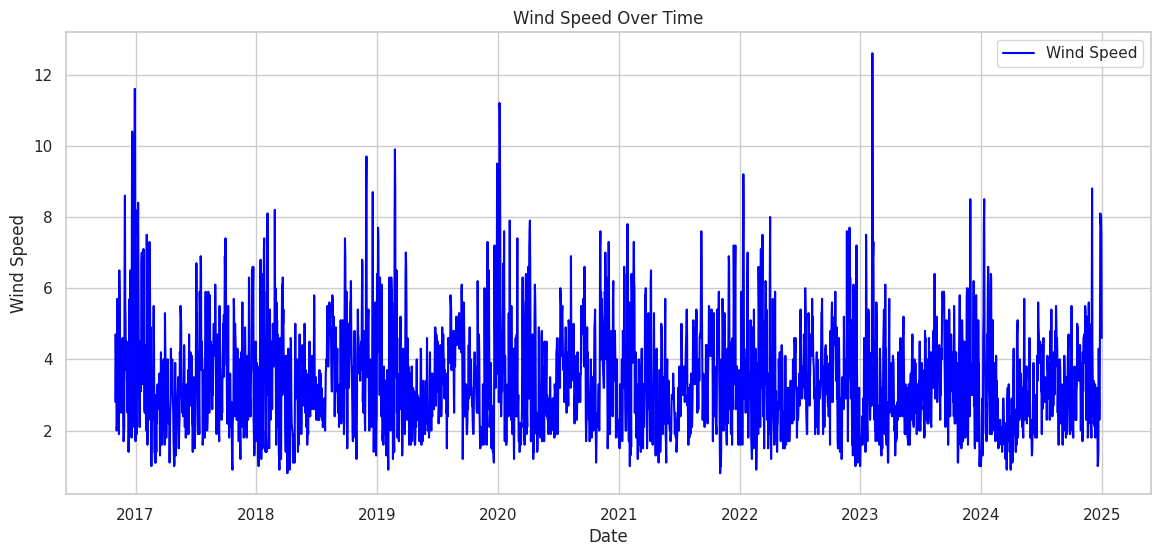

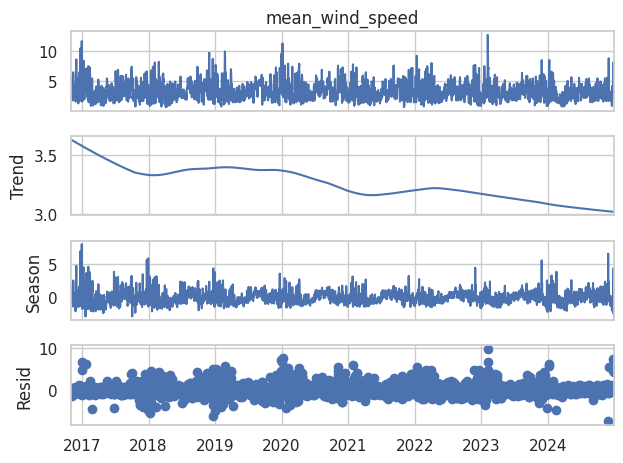

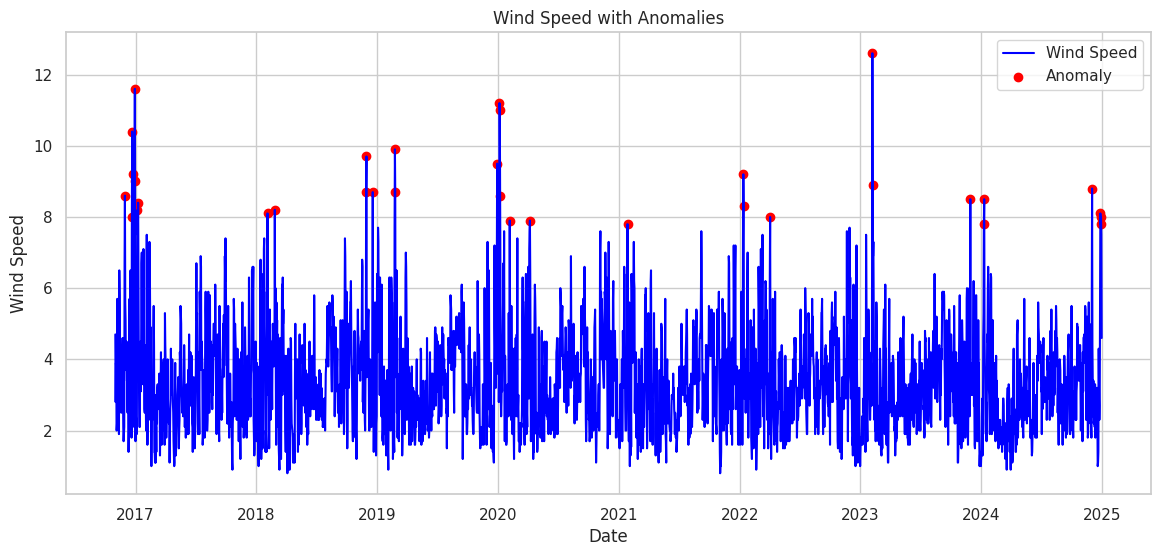

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy import stats

# Load the dataset
file_path = '/content/drive/MyDrive/windforecast/df_FINAL_ENRICHED_UNSCALED.feather'
df = pd.read_feather(file_path)

# Ensure datetime index
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)

# Visualize the data to understand patterns
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['mean_wind_speed'], label='Wind Speed', color='blue')
plt.title('Wind Speed Over Time')
plt.xlabel('Date')
plt.ylabel('Wind Speed')
plt.legend()
plt.show()

# Seasonal decomposition using STL
stl = STL(df['mean_wind_speed'], period=365, robust=True)  # Assuming daily data with annual seasonality
result = stl.fit()

# Visualize the decomposition components
result.plot()
plt.show()

# Function to create time-based features
def add_time_features(df):
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    # Additional flexible time features can be added here
    return df

# Add time features
df = add_time_features(df)

# Anomaly Detection using Z-score
df['z_score'] = np.abs(stats.zscore(df['mean_wind_speed']))
df['is_anomaly'] = df['z_score'] > 3  # Threshold can be adjusted

# Visualize anomalies
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['mean_wind_speed'], label='Wind Speed', color='blue')
plt.scatter(df[df['is_anomaly']].index, df[df['is_anomaly']]['mean_wind_speed'], color='red', label='Anomaly')
plt.title('Wind Speed with Anomalies')
plt.xlabel('Date')
plt.ylabel('Wind Speed')
plt.legend()
plt.show()

In [ ]:
# First, install and use the SciencePlots library for enhanced plots
!pip install SciencePlots
import matplotlib.pyplot as plt
import scienceplots  # Apply SciencePlots style

# Apply SciencePlots style
plt.style.use(['science', 'ieee', 'grid', 'no-latex'])

import pandas as pd
import numpy as np
from scipy import stats

# Load the dataset
file_path = '/content/drive/MyDrive/windforecast/df_FINAL_ENRICHED_UNSCALED.feather'
df = pd.read_feather(file_path)

# Ensure datetime index
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)
df.sort_index(inplace=True)

# Define a function to split data into training and testing sets based on year
def split_data_by_year(df, cutoff_year):
    train_df = df[df.index.year < cutoff_year]
    val_test_df = df[df.index.year >= cutoff_year]
    return train_df, val_test_df

# Split data: training up to 2024 (exclusive), validation/test in 2024
train_df, val_test_df = split_data_by_year(df, 2024)

# Function to add time features
def add_time_features(df):
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    return df

# Add time features to training and validation/test sets
train_df = add_time_features(train_df)
val_test_df = add_time_features(val_test_df)

# Function to calculate rolling features without leakage
def add_rolling_features(df, window_size=30):
    df['rolling_mean'] = df['mean_wind_speed'].rolling(window=window_size, min_periods=1).mean()
    df['rolling_std'] = df['mean_wind_speed'].rolling(window=window_size, min_periods=1).std()
    return df

# Add rolling features to training set
train_df = add_rolling_features(train_df)

# Function to simulate expanding window feature computation for validation/test sets
def apply_expanding_rolling_features(train_df, val_test_df, window_size=30):
    # Full history up to the start of validation/test period
    historical_data = train_df['mean_wind_speed']

    # Iterate over each date in validation/test period and compute rolling features
    for idx in range(len(val_test_df)):
        current_date = val_test_df.index[idx]
        # Compute rolling features using data up to current date
        current_historical_data = pd.concat([historical_data, val_test_df['mean_wind_speed'][:idx+1]])

        # Calculate rolling features
        rolling_mean = current_historical_data.rolling(window=window_size, min_periods=1).mean().iloc[-1]
        rolling_std = current_historical_data.rolling(window=window_size, min_periods=1).std().iloc[-1]

        # Assign computed features
        val_test_df.loc[current_date, 'rolling_mean'] = rolling_mean
        val_test_df.loc[current_date, 'rolling_std'] = rolling_std

    return val_test_df

val_test_df = apply_expanding_rolling_features(train_df, val_test_df)

# Anomaly Detection on all of training sets
train_df['z_score'] = np.abs(stats.zscore(train_df['mean_wind_speed']))
train_df['is_anomaly'] = (train_df['z_score'] > 3).astype(int)

# Anomaly Detection on validation/test sets
val_test_df['z_score'] = np.abs(stats.zscore(val_test_df['mean_wind_speed']))
val_test_df['is_anomaly'] = (val_test_df['z_score'] > 3).astype(int)


# Enhanced visualization
plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_df.index, train_df['mean_wind_speed'], label='Training Data', color='blue', linewidth=2, alpha=0.7)

# Plot validation/test data
plt.plot(val_test_df.index, val_test_df['mean_wind_speed'], label='Validation/Test Data', color='orange', linewidth=2, alpha=0.7)

# Highlight anomalies in training data
plt.scatter(train_df[train_df['is_anomaly']].index, train_df[train_df['is_anomaly']]['mean_wind_speed'],
            color='red', label='Anomaly', s=50, alpha=0.7)

plt.title('Train/Validation-Test Split of Mean Wind Speed Data', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Mean Wind Speed', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare features and target for modeling
def prepare_features_and_target(df, target_col='mean_wind_speed'):
    features = df.drop(columns=[target_col])
    target = df[target_col]
    return features, target

# Prepare data for modeling
X_train, y_train = prepare_features_and_target(train_df)
X_val_test, y_val_test = prepare_features_and_target(val_test_df)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_test_scaled = scaler.transform(X_val_test)

# Define a function to evaluate models
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# SARIMA Model Training and Evaluation
# def train_sarima(y_train, y_test):
#     # SARIMA requires time-series data structure
#     model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 365))
#     model_fit = model.fit(disp=False)
#     predictions = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, typ='levels')
#     evaluate_model(y_test, predictions, "SARIMA")
#     return predictions

# XGBoost Model Training and Evaluation
def train_xgboost(X_train, y_train, X_test, y_test):
    model = XGBRegressor()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    evaluate_model(y_test, predictions, "XGBoost")
    return predictions

# Define LSTM Model
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        LSTM(50),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Train and evaluate models
print("Training and Evaluating Models...")
# sarima_preds = train_sarima(y_train, y_val_test)
xgb_preds = train_xgboost(X_train_scaled, y_train, X_val_test_scaled, y_val_test)

# Reshape data for LSTM: [samples, time steps, features]
# Assuming a simple transformation; real-world data might need careful reshaping
def prepare_lstm_data(X, y, time_steps=30):
    X_lstm, y_lstm = [], []
    for i in range(time_steps, len(X)):
        X_lstm.append(X[i-time_steps:i, :])
        y_lstm.append(y[i])
    return np.array(X_lstm), np.array(y_lstm)

time_steps = 30
X_train_lstm, y_train_lstm = prepare_lstm_data(X_train_scaled, y_train, time_steps)
X_val_test_lstm, y_val_test_lstm = prepare_lstm_data(X_val_test_scaled, y_val_test, time_steps)

# Train LSTM model
lstm_model = create_lstm_model((time_steps, X_train_scaled.shape[1]))
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=1)
lstm_preds = lstm_model.predict(X_val_test_lstm).flatten()
evaluate_model(y_val_test_lstm, lstm_preds[:len(y_val_test_lstm)], "LSTM")

Training and Evaluating Models...
XGBoost - RMSE: 0.27, MAE: 0.21, R²: 0.96


/tmp/ipython-input-17-2092961322.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_lstm.append(y[i])
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: nan
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: nan
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: nan
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: nan
Epoch 5/10
41/81 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: nan

KeyboardInterrupt: 

In [ ]:
train_df.head()

,max_humidity_at_ganos,mean_speed_hayrabolu_horizontal,max_wind_speed_vertical,min_pressure,max_speed_havsa_horizontal,max_speed_meric_vertical,min_temperature,mean_speed_meric_horizontal,max_speed_saray_vertical,mean_speed_enez_horizontal,max_speed_lalapasa_horizontal,max_speed_tekirdag_horizontal,max_speed_havsa_vertical,min_humidity_at_ganos,max_speed_uzunkopru_vertical,max_temperature,mean_speed_kesan_horizontal,max_speed_edirne_vertical,max_speed_meric_horizontal,mean_speed_meric_vertical,mean_wind_speed,max_speed_tekirdag_vertical,mean_speed_muratli_vertical,max_speed_uzunkopru_horizontal,mean_speed_enez_vertical,max_speed_malkara_horizontal,max_speed_kesan_horizontal,mean_speed_malkara_horizontal,mean_wind_speed_horizontal,mean_speed_muratli_horizontal,max_speed_muratli_horizontal,mean_temperature,mean_speed_cerkezkoy_horizontal,mean_speed_lalapasa_vertical,mean_speed_saray_horizontal,mean_speed_ipsala_horizontal,max_speed_marmara_vertical,max_wind_speed,max_speed_cerkezkoy_horizontal,max_speed_muratli_vertical,max_speed_saray_horizontal,max_speed_cerkezkoy_vertical,max_speed_enez_horizontal,max_speed_corlu_vertical,max_wind_speed_horizontal,max_speed_enez_vertical,max_humidity,mean_speed_edirne_vertical,mean_speed_lalapasa_horizontal,mean_speed_havsa_horizontal,mean_speed_hayrabolu_vertical,max_pressure,mean_speed_uzunkopru_horizontal,total_precipitation_at_ganos,mean_humidity_at_ganos,min_humidity,max_temperature_at_ganos,mean_speed_malkara_vertical,mean_speed_uzunkopru_vertical,mean_speed_cerkezkoy_vertical,mean_speed_marmara_vertical,max_speed_hayrabolu_vertical,max_speed_ipsala_vertical,max_speed_kesan_vertical,mean_speed_ipsala_vertical,mean_speed_kesan_vertical,mean_speed_havsa_vertical,max_speed_hayrabolu_horizontal,mean_speed_tekirdag_vertical,max_speed_edirne_horizontal,mean_speed_corlu_horizontal,max_speed_malkara_vertical,max_speed_corlu_horizontal,mean_speed_marmara_horizontal,max_speed_ipsala_horizontal,...,square_max_speed_corlu_horizontal,abs_mean_speed_marmara_horizontal,square_mean_speed_marmara_horizontal,abs_max_speed_ipsala_horizontal,square_max_speed_ipsala_horizontal,abs_max_speed_marmara_horizontal,square_max_speed_marmara_horizontal,abs_mean_wind_speed_vertical,square_mean_wind_speed_vertical,abs_mean_speed_saray_vertical,square_mean_speed_saray_vertical,abs_max_speed_lalapasa_vertical,square_max_speed_lalapasa_vertical,abs_mean_speed_tekirdag_horizontal,square_mean_speed_tekirdag_horizontal,abs_mean_speed_edirne_horizontal,square_mean_speed_edirne_horizontal,abs_mean_speed_corlu_vertical,square_mean_speed_corlu_vertical,air_density,potential_temp_c,wind_power_proxy,diurnal_temp_range,dew_point_approx,dryness_index,wind_power_moisture,sarkoy_u_comp,sarkoy_v_comp,sarkoy_max_u_comp,sarkoy_max_v_comp,days_since_high_wind,lunar_sin,lunar_cos,sarkoy_rain_event,sarkoy_log_precipitation,sarkoy_days_since_last_rain,sarkoy_light_rain,sarkoy_moderate_rain,sarkoy_heavy_rain,sarkoy_annual_cum_precip,ganos_rain_event,ganos_log_precipitation,ganos_days_since_last_rain,ganos_light_rain,ganos_moderate_rain,ganos_heavy_rain,ganos_annual_cum_precip,sarkoy_consecutive_rain_event_days,ganos_consecutive_rain_event_days,sarkoy_wind_dir_streak,temp_diff_sarkoy_ganos,hum_diff_sarkoy_ganos,temp_diff_sarkoy_ganos_lag_1,temp_diff_sarkoy_ganos_lag_2,hum_diff_sarkoy_ganos_lag_1,hum_diff_sarkoy_ganos_lag_2,mean_wind_speed_roll_3_volatility,mean_wind_speed_roll_7_volatility,mean_wind_speed_roll_14_volatility,mean_wind_speed_roll_21_volatility,mean_wind_speed_roll_30_volatility,target,wind_dir_E,wind_dir_N,wind_dir_NE,wind_dir_NW,wind_dir_S,wind_dir_SE,wind_dir_SW,wind_dir_W,wind_dir_Unknown,rolling_mean,rolling_std,z_score,is_anomaly
date_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-11-01,77.0,3.181981,-12.618104,1021.7,3.391512,-11.798203,5.6,-0.271774,-5.796986,-1.600000,10.862031,9.158712e+00,-11.093135,75.0,

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

# Load the dataset
file_path = '/content/drive/MyDrive/windforecast/df_FINAL_ENRICHED_UNSCALED.feather'
df = pd.read_feather(file_path)

# Ensure datetime index
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)
df.sort_index(inplace=True)

# Split data: training up to 2024 (exclusive), validation/test in 2024
train_df = df[df.index.year < 2024]
val_test_df = df[df.index.year >= 2024]

# Function to add time features
def add_time_features(df):
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    return df

# Add time features
train_df = add_time_features(train_df)
val_test_df = add_time_features(val_test_df)

# Function to calculate rolling features using expanding window
def add_rolling_features_expanding(df, target_col='mean_wind_speed', window_size=30):
    df['rolling_mean'] = df[target_col].expanding(min_periods=window_size).mean()
    df['rolling_std'] = df[target_col].expanding(min_periods=window_size).std()
    return df

# Apply expanding window rolling features
train_df = add_rolling_features_expanding(train_df)
val_test_df = add_rolling_features_expanding(val_test_df)

# Function to compute anomaly detection using expanding window
def compute_anomalies_expanding(df, target_col='mean_wind_speed'):
    # Calculate expanding mean and std for dynamic anomaly detection
    df['expanding_mean'] = df[target_col].expanding().mean()
    df['expanding_std'] = df[target_col].expanding().std()

    # Calculate z-score using expanding statistics
    df['z_score'] = np.abs((df[target_col] - df['expanding_mean']) / df['expanding_std'])
    df['is_anomaly'] = (df['z_score'] > 3).astype(int)
    return df

train_df = compute_anomalies_expanding(train_df)
val_test_df = compute_anomalies_expanding(val_test_df)

# Prepare data for modeling
def prepare_features_and_target(df, target_col='target'):
    # Exclude columns that shouldn't be features, e.g., target and expanding stats used for anomaly detection
    features = df.drop(columns=[target_col])
    target = df[target_col]
    return features, target

X_train, y_train = prepare_features_and_target(train_df)
X_val_test, y_val_test = prepare_features_and_target(val_test_df)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_test_scaled = scaler.transform(X_val_test)

# Define a function to evaluate models with MAPE
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}, MAPE: {mape:.2%}")

# SARIMA Model Training and Evaluation
# def train_sarima(y_train, y_test):
#     model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 365))
#     model_fit = model.fit(disp=False)
#     predictions = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, typ='levels')
#     evaluate_model(y_test, predictions, "SARIMA")
#     return predictions

# XGBoost Model Training and Evaluation
def train_xgboost(X_train, y_train, X_test, y_test):
    model = XGBRegressor()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    evaluate_model(y_test, predictions, "XGBoost")
    return predictions

# Train and evaluate models
print("Training and Evaluating Models...")
# sarima_preds = train_sarima(y_train, y_val_test)
xgb_preds = train_xgboost(X_train_scaled, y_train, X_val_test_scaled, y_val_test)


/tmp/ipython-input-20-1336107231.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_of_year'] = df.index.dayofyear
/tmp/ipython-input-20-1336107231.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df.index.month
/tmp/ipython-input-20-1336107231.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

Training and Evaluating Models...
XGBoost - RMSE: 1.02, MAE: 0.79, R²: 0.39, MAPE: 29.15%


In [ ]:
df.columns.values

array(['max_humidity_at_ganos', 'mean_speed_hayrabolu_horizontal',
       'max_wind_speed_vertical', 'min_pressure',
       'max_speed_havsa_horizontal', 'max_speed_meric_vertical',
       'min_temperature', 'mean_speed_meric_horizontal',
       'max_speed_saray_vertical', 'mean_speed_enez_horizontal',
       'max_speed_lalapasa_horizontal', 'max_speed_tekirdag_horizontal',
       'max_speed_havsa_vertical', 'min_humidity_at_ganos',
       'max_speed_uzunkopru_vertical', 'max_temperature',
       'mean_speed_kesan_horizontal', 'max_speed_edirne_vertical',
       'max_speed_meric_horizontal', 'mean_speed_meric_vertical',
       'mean_wind_speed', 'max_speed_tekirdag_vertical',
       'mean_speed_muratli_vertical', 'max_speed_uzunkopru_horizontal',
       'mean_speed_enez_vertical', 'max_speed_malkara_horizontal',
       'max_speed_kesan_horizontal', 'mean_speed_malkara_horizontal',
       'mean_wind_speed_horizontal', 'mean_speed_muratli_horizontal',
       'max_speed_muratli_horizontal

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL

# Load the dataset
file_path = '/content/drive/MyDrive/windforecast/df_FINAL_ENRICHED_UNSCALED.feather'
df = pd.read_feather(file_path)

# Ensure datetime index
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)
df.sort_index(inplace=True)

# Create lag features for the last two days
# df['lag_1'] = df['mean_wind_speed'].shift(1)  # Yesterday
# Get a list of physical columns so that we can get their previous day values
phys_cols = [col for col in df.columns if 'mean' in col]
for col in phys_cols:
    df[f'{col}_yest'] = df[col].shift(1)

phys_cols = [col for col in df.columns if 'min' in col]
for col in phys_cols:
    df[f'{col}_yest'] = df[col].shift(1)

phys_cols = [col for col in df.columns if 'max' in col]
for col in phys_cols:
    df[f'{col}_yest'] = df[col].shift(1)

# Rolling statistics over a 365-day window
df['rolling_mean_365'] = df['mean_wind_speed'].rolling(window=365, min_periods=1).mean()
df['rolling_std_365'] = df['mean_wind_speed'].rolling(window=365, min_periods=1).std()

# Interaction features between temperature, humidity, and wind speed
df['temp_humidity_interaction'] = df['mean_temperature'] * df['mean_humidity_at_ganos']
df['temp_wind_interaction'] = df['mean_temperature'] * df['mean_wind_speed']

# Wind direction stability features
df['wind_dir_E_stability'] = df['wind_dir_E'].rolling(window=5).std()  # Example for one direction
df['wind_dir_N_stability'] = df['wind_dir_N'].rolling(window=5).std()  # Example for one direction
df['wind_dir_W_stability'] = df['wind_dir_W'].rolling(window=5).std()  # Example for one direction
df['wind_dir_S_stability'] = df['wind_dir_S'].rolling(window=5).std()  # Example for one direction
df['wind_dir_NE_stability'] = df['wind_dir_NE'].rolling(window=5).std()  # Example for one direction
df['wind_dir_NW_stability'] = df['wind_dir_NW'].rolling(window=5).std()  # Example for one direction
df['wind_dir_SE_stability'] = df['wind_dir_SE'].rolling(window=5).std()  # Example for one direction
df['wind_dir_SW_stability'] = df['wind_dir_SW'].rolling(window=5).std()

# Impact of precipitation on wind speed
df['precip_wind_interaction'] = df['total_precipitation'].shift(1) * df['mean_wind_speed']

# Days-since features for other weather events
df['days_since_high_temp'] = (df['mean_temperature'] > df['mean_temperature'].quantile(0.95)).groupby(df.index).cumsum()

# Cross-location features
# df['wind_speed_ratio'] = df['mean_wind_speed'] / df['mean_speed_meric_horizontal']

# Seasonal decomposition using STL
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL

# Load the dataset
file_path = '/content/drive/MyDrive/windforecast/df_FINAL_ENRICHED_UNSCALED.feather'
df = pd.read_feather(file_path)

# Ensure datetime index
df['date_time'] = pd.to_datetime(df['date_time'])
df.set_index('date_time', inplace=True)
df.sort_index(inplace=True)

# Split data: training up to 2024 (exclusive), validation/test in 2024
train_df = df[df.index.year < 2024]
val_test_df = df[df.index.year >= 2024]

# Perform STL decomposition on training data only
stl = STL(train_df['mean_wind_speed'], period=365, robust=True)
result = stl.fit()

# Add decomposed components as features to the training set
train_df['seasonal'] = result.seasonal
train_df['trend'] = result.trend
train_df['residual'] = result.resid

# Function to predict seasonal component for future dates based on historical patterns
def predict_seasonal_component(date, seasonal_component, historical_index):
    # Match the date to the same day in previous years to estimate seasonal component
    matching_dates = historical_index[(historical_index.day == date.day) & (historical_index.month == date.month)]
    if not matching_dates.empty:
        # Average seasonal component for matching historical dates
        return seasonal_component.loc[matching_dates].mean()
    return seasonal_component.mean()  # Default to mean seasonal effect if no match found

# Applying seasonal and trend estimation for validation/test sets
for idx in val_test_df.index:
    seasonal_val = predict_seasonal_component(idx, train_df['seasonal'], train_df.index)
    trend_val = train_df['trend'].iloc[-1]  # Continue from the last known trend value

    # Assign these values to the validation/test set
    val_test_df.loc[idx, 'seasonal'] = seasonal_val
    val_test_df.loc[idx, 'trend'] = trend_val

# Calculate residuals for validation/test sets
val_test_df['residual'] = val_test_df['mean_wind_speed'] - val_test_df['seasonal'] - val_test_df['trend']

# Rolling statistics using expanding window for validation/test sets
for idx in val_test_df.index:
    # Get historical data up to the current index (excluding current for realistic forecasting)
    historical_data = pd.concat([train_df['mean_wind_speed'], val_test_df.loc[:idx, 'mean_wind_speed']])

    # Calculate rolling statistics with expanding window
    rolling_mean = historical_data.rolling(window=365, min_periods=1).mean().iloc[-1]
    rolling_std = historical_data.rolling(window=365, min_periods=1).std().iloc[-1]

    # Assign rolling features
    val_test_df.loc[idx, 'rolling_mean_365'] = rolling_mean
    val_test_df.loc[idx, 'rolling_std_365'] = rolling_std

# Display the updated dataframes with new features
print("Training Data:")
print(train_df[['mean_wind_speed', 'seasonal', 'trend', 'residual']].head())

print("\nValidation/Test Data:")
print(val_test_df[['mean_wind_speed', 'seasonal', 'trend', 'residual']].head())

# Drop rows with NaN values resulting from lag features
df.dropna(inplace=True)
train_df.dropna(inplace=True)
val_test_df.dropna(inplace=True)

# Display the updated dataframe with new features
print(train_df.head(1))


/tmp/ipython-input-23-986315909.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_yest'] = df[col].shift(1)
/tmp/ipython-input-23-986315909.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_yest'] = df[col].shift(1)
/tmp/ipython-input-23-986315909.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

Training Data:
            mean_wind_speed  seasonal     trend  residual
date_time                                                
2016-11-01              4.7  0.789463  3.635324  0.275213
2016-11-02              2.8 -0.559460  3.634417 -0.274957
2016-11-03              3.9  0.100531  3.633510  0.165959
2016-11-04              3.5  0.036453  3.632604 -0.169057
2016-11-05              2.0 -0.179127  3.631698 -1.452572

Validation/Test Data:
            mean_wind_speed  seasonal    trend  residual
date_time                                               
2024-01-01              1.3 -1.273630  3.10003 -0.526400
2024-01-02              1.3 -1.105288  3.10003 -0.694742
2024-01-03              2.4 -0.497713  3.10003 -0.202318
2024-01-04              2.9 -1.000159  3.10003  0.800129
2024-01-05              1.3 -0.597453  3.10003 -1.202578
            max_humidity_at_ganos  mean_speed_hayrabolu_horizontal  \
date_time                                                            
2016-11-01       

/tmp/ipython-input-23-986315909.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.dropna(inplace=True)
/tmp/ipython-input-23-986315909.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_test_df.dropna(inplace=True)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

# Calculate rolling features for the training and validation/test sets
for df_subset in [train_df, val_test_df]:
    df_subset['rolling_mean_365'] = df_subset['mean_wind_speed'].rolling(window=365, min_periods=1).mean()
    df_subset['rolling_std_365'] = df_subset['mean_wind_speed'].rolling(window=365, min_periods=1).std()
    df_subset.fillna(method='ffill', inplace=True)  # Forward fill NaNs

# Prepare features and target variable
def prepare_data(df, target_col='target'):
    features = df.dropna().drop(columns=[target_col])  # Exclude rolling features if they are based on future data
    target = df.dropna()[target_col]
    return features, target

X_train, y_train = prepare_data(train_df)
X_val_test, y_val_test = prepare_data(val_test_df)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_test_scaled = scaler.transform(X_val_test)

# Define a function to evaluate models with standard metrics
def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2%}, R²: {r2:.2f}")

# Train and evaluate RidgeCV model
def train_ridge(X_train, y_train, X_test, y_test):
    model = RidgeCV(alphas=np.logspace(-6, 6, 13))
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    evaluate_model(y_test, predictions, "RidgeCV")
    return predictions

# Train and evaluate LassoCV model
def train_lasso(X_train, y_train, X_test, y_test):
    model = LassoCV(alphas=np.logspace(-6, 6, 13))
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    evaluate_model(y_test, predictions, "LassoCV")
    return predictions

# Train and evaluate ElasticNetCV model
def train_elasticnet(X_train, y_train, X_test, y_test):
    model = ElasticNetCV(alphas=np.logspace(-6, 6, 13), l1_ratio=[.1, .5, .7, .9, .95, .99, 1])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    evaluate_model(y_test, predictions, "ElasticNetCV")
    return predictions

# Run model training and evaluation
print("Training and Evaluating Models...")
ridge_preds = train_ridge(X_train_scaled, y_train, X_val_test_scaled, y_val_test)
lasso_preds = train_lasso(X_train_scaled, y_train, X_val_test_scaled, y_val_test)
elasticnet_preds = train_elasticnet(X_train_scaled, y_train, X_val_test_scaled, y_val_test)

/tmp/ipython-input-26-2457201284.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['rolling_mean_365'] = df_subset['mean_wind_speed'].rolling(window=365, min_periods=1).mean()
/tmp/ipython-input-26-2457201284.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['rolling_std_365'] = df_subset['mean_wind_speed'].rolling(window=365, min_periods=1).std()
/tmp/ipython-input-26-2457201284.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. 

Training and Evaluating Models...
RidgeCV - RMSE: 1.05, MAE: 0.82, MAPE: 31.27%, R²: 0.36


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 40.67732563541813, tolerance: 0.4304103876864244
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 541.2339099293351, tolerance: 0.4304103876864244
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 834.1979963919359, tolerance: 0.4703698882752032
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergence

LassoCV - RMSE: 1.01, MAE: 0.79, MAPE: 29.35%, R²: 0.41


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.207725057122616, tolerance: 0.4304103876864244
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 430.0267440017809, tolerance: 0.4304103876864244
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 736.878640409952, tolerance: 0.4304103876864244
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceW

ElasticNetCV - RMSE: 1.01, MAE: 0.80, MAPE: 29.71%, R²: 0.40
